# firelab — the architecture, the code, the GUI, and how to run it

There are two notebooks, and they answer different questions.

| Notebook | Question | Contents |
|---|---|---|
| `ARCHITECTURE.ipynb` | **Why** is it built this way? | The design derived from first principles, in self-contained prototype code. Boundaries, contracts, the deployment argument, milestones. |
| `GUIDE.ipynb` *(this one)* | **What** was built, and how do I run it? | The shipped service — every file, every panel, every endpoint, driven live. |

Read `ARCHITECTURE.ipynb` first if you want the reasoning; read this one if you
want the system. They disagree in one place, deliberately: the design proposes
**eleven processes over MQTT**, and what shipped is **one process in three
layers** — `domain/`, `adapters/`, `app/`. Every boundary in the design
survived; only the unit they are drawn in changed, from container to module.
Section 6 of `ARCHITECTURE.ipynb` defends that, and section 2 below shows the
result.

Read this notebook top to bottom the first time. After that, use it as a
reference:

| Section | What you get |
|---|---|
| 0 | Start the two services |
| 1 | Repository map, file by file |
| 2 | Architecture: the data-flow, process, module and front-end views |
| 3 | `domain/` — the pure core, module by module |
| 4 | `adapters/` — everything that speaks to BuildSim |
| 5 | `app/` — the impure edge |
| 6 | The HTTP API |
| 7 | The GUI, panel by panel |
| 8 | A full session, driven from this notebook |
| 9 | Swapping the rule detector for a trained model |
| 10 | What this does not do — the limits of the model |
| 11 | Things that go wrong |

The code cells read the real source files, so nothing here can drift away from
what is on disk.


## 0. Running it

Two services, started in this order.

**BuildSim** owns the building: floor plans, the 3D viewer, the walkable graph.
It is the ground truth for geometry and the only thing the user actually looks
at in 3D.

```bash
cd buildingsim
nohup ./bin/buildsim start --port 9090 > /tmp/buildsim.log 2>&1 &
```

Redirect its output. Its request log is extremely chatty.

**firelab** owns the simulation and the control plane. It builds the UI, then
serves it alongside the API.

```bash
cd firelab
make build      # venv + python deps + npm install + vite build
make run        # uvicorn on 127.0.0.1:8090
```

Then open <http://127.0.0.1:8090/> for the control panel and
<http://127.0.0.1:9090/> for the 3D viewer. Put them side by side — firelab
drives the viewer.

### Makefile targets

| Target | What it does |
|---|---|
| `make deps` | create `.venv` (via `uv`, falling back to `python3 -m venv`) and install requirements |
| `make ui` | `npm install` in `ui/` |
| `make build` | `deps` + `ui` + `vite build` into `ui/dist` |
| `make run` | uvicorn, serving `ui/dist` at `/` |
| `make dev` | uvicorn with `--reload`, for editing Python |
| `make test` | pytest: the domain units, the layering guards, and one end-to-end run per preset; needs nothing running |
| `make clean` | remove `.venv`, `node_modules`, `dist` |

### Restarting cleanly

SSE streams never end on their own, so a plain kill leaves the publisher hanging.
Always pass the graceful-shutdown timeout:

```bash
pkill -f 'uvicorn firelab.app.main'
.venv/bin/uvicorn firelab.app.main:app --app-dir .. --host 127.0.0.1 --port 8090 \
    --timeout-graceful-shutdown 3
```

**Do not run `occupancysim` at the same time.** It and firelab both do a full
replace on `PUT /api/entities` and `PUT /api/occupancy`; together they erase each
other's people.

In [1]:
import json
import sys
import urllib.request
from pathlib import Path

FIRELAB = 'http://127.0.0.1:8090'    # this project: the simulation + control plane
BUILDSIM = 'http://127.0.0.1:9090'   # the separate Go service that draws the building in 3D

# The notebook lives in firelab/, so the package root is one level up.
ROOT = Path.cwd() if Path.cwd().name == 'firelab' else Path.cwd() / 'firelab'
sys.path.insert(0, str(ROOT.parent))  # makes `import firelab...` work in later cells


def api(path, method='GET', body=None, base=FIRELAB):
    """Send one HTTP request and return the reply already decoded from JSON.

    `body` is an ordinary Python dict and is converted to JSON for you.
    Every later cell calls this instead of repeating the urllib boilerplate.
    """
    data = json.dumps(body).encode() if body is not None else None
    request = urllib.request.Request(
        base + path, data=data, method=method,
        headers={'content-type': 'application/json'},
    )
    with urllib.request.urlopen(request, timeout=30) as response:
        return json.loads(response.read() or 'null')


# Check both services are running. Everything below this cell depends on it.
try:
    print('firelab  ', api('/healthz'))
    building = api('/api/building', base=BUILDSIM)
    print('buildsim ', building['name'], [level['id'] for level in building['levels']])
except Exception as exc:
    print('not reachable:', exc)
    print('start both services as described above, then re-run this cell')


firelab   {'ok': True, 'buildsim': True}
buildsim  A-Building (LTU) ['level0', 'level1', 'level2']


## 1. Repository map

Every file, and the one thing it is responsible for.

In [2]:
import ast


# Every module opens with a docstring whose first line states its one job. The
# map below is read out of the code, so it cannot drift out of date the way a
# hand-written list does.
def purpose(path):
    doc = ast.get_docstring(ast.parse(path.read_text())) or ''
    return doc.strip().splitlines()[0] if doc else '-'


total = 0
for folder in ('domain', 'adapters', 'app'):
    print(f'\n{folder}/')
    for path in sorted((ROOT / folder).rglob('*.py')):
        if '__pycache__' in path.parts:
            continue
        lines = len(path.read_text().splitlines())
        total += lines
        name = str(path.relative_to(ROOT / folder))
        print(f'  {name:<24} {lines:>4}  {purpose(path)}')

print(f'\n{total} lines of Python, and no file long enough to get lost in.')

# The front end: one .svelte file per panel of the interface.
ui = sorted(p.name for p in (ROOT / 'ui' / 'src').rglob('*.svelte'))
print()
print('ui/src:', ', '.join(ui))



domain/
  __init__.py                 4  Pure domain: no network, no clock, no configuration.
  agent.py                  148  The alarm state machine: NORMAL -> INVESTIGATING -> PRE_ALARM -> CONFIRMED -> SUPPRESSED.
  detector.py               112  P(fire) per space.
  features.py                92  Readings -> feature vectors. Nothing here may see the truth.
  history.py                 51  A short rolling record per space, for the charts and the CSV export.
  interlocks.py              47  Safety rules the agent cannot override.
  occupants.py              101  Occupants: where they are and how they follow a route. Pure.
  physics.py                 86  Lumped per-space fire physics over the building adjacency graph.
  roles.py                   30  Who is in the building, and how well they get themselves out.
  scoring.py                107  Grade the system against the ground truth the sources carry.
  sensing.py                120  The boundary where truth becomes observation.
 

## 2. Architecture

### Start here: what the system actually is

Before any diagram, the one-sentence version:

> firelab **simulates a fire** in a real building, **pretends to watch it** through
> imperfect smoke detectors, and then tries to **work out that there is a fire**
> from those readings alone — while getting the people out.

Everything in this section follows from one uncomfortable fact:

> **A fire alarm cannot see the fire.** It only sees what its sensors report, and
> sensors are slow, noisy, biased, and sometimes broken.

If you remember nothing else, remember that the whole codebase is arranged around
keeping those two things apart.

### The one idea: truth and belief

The system is split down the middle into two halves that are never allowed to
touch:

| Half | Knows | Lives in |
|---|---|---|
| **Truth** — what is really happening | the exact heat, smoke and CO in every room | `domain/physics.py`, `app/engine/truth.py` |
| **Belief** — what the system thinks is happening | only the numbers sensors reported | `domain/detector.py`, `domain/agent.py`, `app/engine/intelligence.py` |

Think of a doctor and a patient. The patient has an actual condition; the doctor
only has a thermometer and some questions. Medicine is hard *because* the doctor
cannot read the diagnosis directly — and if they could, there would be no skill
in it.

Same here. If the detector were allowed to read the true smoke level, it would be
right every single time and the project would prove nothing. **The gap between
the two halves is the entire subject.** False alarms live in that gap. So do
missed fires.

This is why the diagrams below are colour-coded: **red boxes hold truth, blue
boxes hold belief**, and there is exactly one arrow from red to blue — the
sensors.

### The vocabulary, once

These words appear on every page from here on. They all mean something specific
and small.

| Word | What it means here |
|---|---|
| **tick** | one step of the simulation. The loop runs a tick every 0.25 s and recomputes everything. |
| **snapshot** | the entire state of the simulation flattened into one JSON object. Pushed to the browser once per *simulated* second, so speeding the clock up speeds the updates up too. |
| **space** | one room. `Space` holds its temperature, smoke, CO and whether its sprinkler is on. |
| **coupling** | one doorway joining two spaces. How open it is decides how fast smoke moves through. |
| **source** | whatever is burning — or merely smoking, like a kettle. Each carries a hidden label saying whether it is a real fire. |
| **device** | one deployed sensor. Each has its own lag and its own built-in error, which is why two detectors in one room disagree. |
| **reading** | what a device reports. Not the truth — the truth after lag, noise, drift and rounding. |
| **feature** | a number derived from recent readings, e.g. how fast smoke is rising. Features are what the detector judges. |
| **detector** | turns features into `P(fire)`, a probability between 0 and 1. |
| **agent** | one small state machine per room — `NORMAL → INVESTIGATING → PRE_ALARM → CONFIRMED → SUPPRESSED → CLEARING` — that decides when a probability becomes an alarm. The waiting between states is what stops a single noisy reading ringing the bell. |
| **command** | a request to change something physical, e.g. "sprinkler on". The agent asks; it never acts. |
| **interlock** | a safety check a command must pass before anything happens. This is why the agent asks. |
| **tenability** | whether a room is still survivable for a person — heat, smoke and toxic dose combined. |
| **pure** | a function that only reads its arguments and returns a value: no network, no clock, no saved state. Pure code can be tested with nothing else running. |
| **adapter** | code whose only job is to talk to something external — here, BuildSim over HTTP. |
| **SSE** | *server-sent events*. A connection the server holds open and pushes updates down. The browser never has to ask "anything new?". |

### Four views, and why you need all four

A house has a floor plan, a wiring diagram and a plumbing diagram. Nobody argues
about which is the real house. Same building, three questions.

This system gets four:

| View | The question it answers | Read it when you want to know |
|---|---|---|
| **2.1 Data flow** | what happens to a puff of smoke, from ignition to the alarm on screen | *how does it work?* |
| **2.2 Process** | what is running, on which port, and what is sent over each wire | *what do I have to start, and why is it lagging?* |
| **2.3 Module** | which file may import which, and where the pure code stops | *where does my change belong?* |
| **2.4 Front end** | how one store feeds every panel, and how commands get back out | *why did that number on screen change?* |

These are views of what **shipped**. For *why* each boundary sits where it does,
see sections 8 and 6 of `ARCHITECTURE.ipynb`.


### 2.1 The data-flow view — the four zones

This view follows one puff of smoke, from the moment something catches fire to
the moment a red row appears on your screen. It is the view to learn first,
because the other three are just different ways of cutting the same journey up.

The pipeline is split into four zones that mirror the physical reality:

1. **WORLD** — what is actually happening. Heat, smoke, CO, people, doors.
2. **SENSING** — corrupts the truth into readings. Lag, noise, drift, dead sensors.
3. **INTELLIGENCE** — sees *only* readings. Features, P(fire), the alarm state machine.
4. **ACTUATION** — commands, checked by interlocks, applied back into the world.

The intelligence zone never touches the world directly. That is not a stylistic
choice: it is what makes the false-alarm question meaningful. If the detector
could read `space.smoke` it would be perfect and the exercise would be pointless.

The zones are also files: `truth.py` (WORLD and SENSING), `intelligence.py` and
`actuation.py`, all in `app/engine/`. So the rule "intelligence may not read the
truth" is something you can check by opening one file, rather than something you
have to take on trust.

In the diagram below, red boxes hold the truth and blue boxes hold the belief.
The only path from red to blue runs through SENSING — and that is exactly where
every blind spot in the system is introduced.


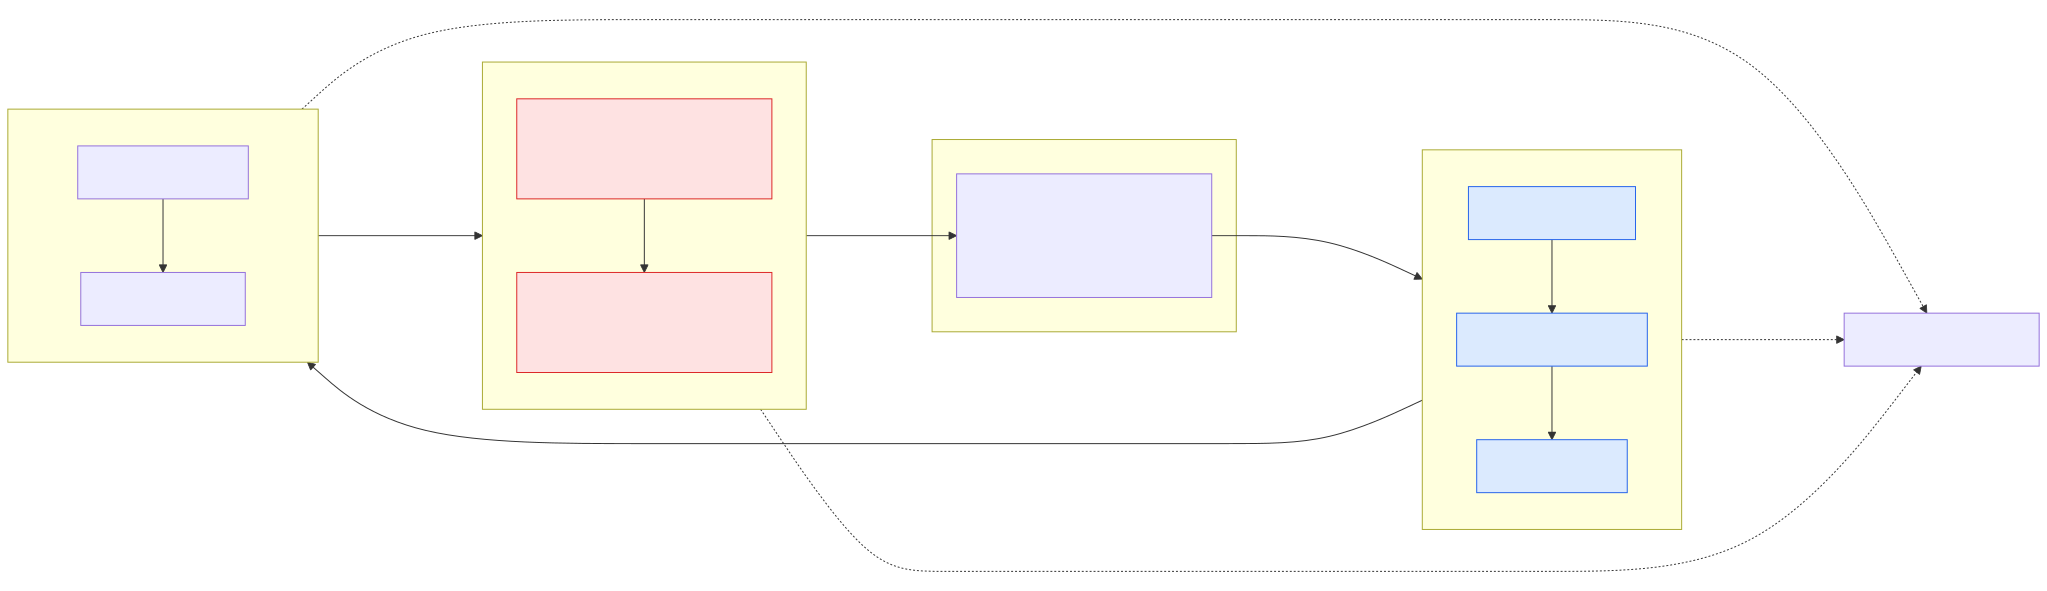

In [3]:
import base64
import urllib.request

from IPython.display import SVG, Markdown, display

_MERMAID_ENDPOINT = 'https://mermaid.ink/svg/'


def mermaid(source, timeout=30):
    """Turn Mermaid diagram text into a picture.

    Mermaid is a plain-text way of describing diagrams. The free mermaid.ink
    service draws it: the text is base64-encoded into the URL, and the reply is
    an SVG image. With no internet, the diagram text is shown instead.
    """
    payload = base64.urlsafe_b64encode(source.strip().encode()).decode()
    request = urllib.request.Request(
        _MERMAID_ENDPOINT + payload,
        headers={'User-Agent': 'Mozilla/5.0'},  # the service rejects urllib's default agent
    )
    try:
        with urllib.request.urlopen(request, timeout=timeout) as response:
            display(SVG(response.read().decode()))
    except Exception as exc:
        display(Markdown(f'> Diagram not rendered ({exc}).\n\n```mermaid\n{source.strip()}\n```'))


# One box per zone, labelled with the module that owns it. Solid arrows are the
# tick pipeline; dotted arrows are what gets drawn in the 3D viewer. Red boxes
# hold the truth, blue boxes the belief — and no arrow runs from a red box into
# a blue one except through SENSING.
mermaid('''
flowchart LR
    subgraph WORLD["1 - WORLD: what is actually happening"]
        direction TB
        SRC["sources.emission<br/>heat, smoke, CO per source"]
        PHY["truth.advance -> physics.step<br/>lag + diffusion per room"]
        SRC --> PHY
    end

    subgraph SENSING["2 - SENSING: truth spoiled into readings"]
        SEN["truth.sense -> sensing.sample<br/>lag, bias, noise, quantise, faults"]
    end

    subgraph INTEL["3 - INTELLIGENCE: readings only"]
        direction TB
        FEA["features.extract"]
        DET["detector.probability"]
        AGT["agent.update"]
        FEA --> DET
        DET --> AGT
    end

    subgraph ACT["4 - ACTUATION: nothing moves unchecked"]
        direction TB
        INT["interlocks.check"]
        APP["actuation.apply"]
        INT --> APP
    end

    PHY -- "true values" --> SEN
    SEN -- "readings" --> FEA
    AGT -- "commands" --> INT
    APP -- "sprinklers, doors" --> PHY

    PHY -. "room layers, smoke" .-> BS["BuildSim 3D viewer"]
    AGT -. "alerts, highlights" .-> BS
    APP -. "routes, people" .-> BS

    classDef truth fill:#fee2e2,stroke:#dc2626
    classDef belief fill:#dbeafe,stroke:#2563eb
    class SRC,PHY truth
    class FEA,DET,AGT belief
''')


### 2.2 The process view — what is actually running

A **process** is one program running on your computer. If you opened a task
manager while this is going, you would see exactly two of them, plus your
browser. That is the whole system.

Two operating-system processes and one browser, nothing else. Blue is code in
this repository; grey is BuildSim, which is a separate Go service you did not
write and only read from and write to over HTTP.

| Wire | Direction | Carries |
|---|---|---|
| `REST :8090` | panel → firelab | every button press: ignite, deploy, clock, command |
| `SSE /api/events` | firelab → panel | one snapshot per publish; the UI never polls for state |
| `REST :9090` | firelab → BuildSim | layers, effects, alerts, doors, entities, occupancy, highlights, routes |
| `REST :9090` | BuildSim → firelab | floor plans and walkable routes, read at startup and on demand |
| viewer socket | BuildSim → 3D tab | BuildSim pushes its own scene updates; firelab is not involved |

Two consequences worth noticing. First, **firelab never draws anything** — it

only writes state into BuildSim, which does the drawing. Second, the control

panel and the 3D view are updated down two independent paths, which is why theviewer can lag the panel by a publish interval.

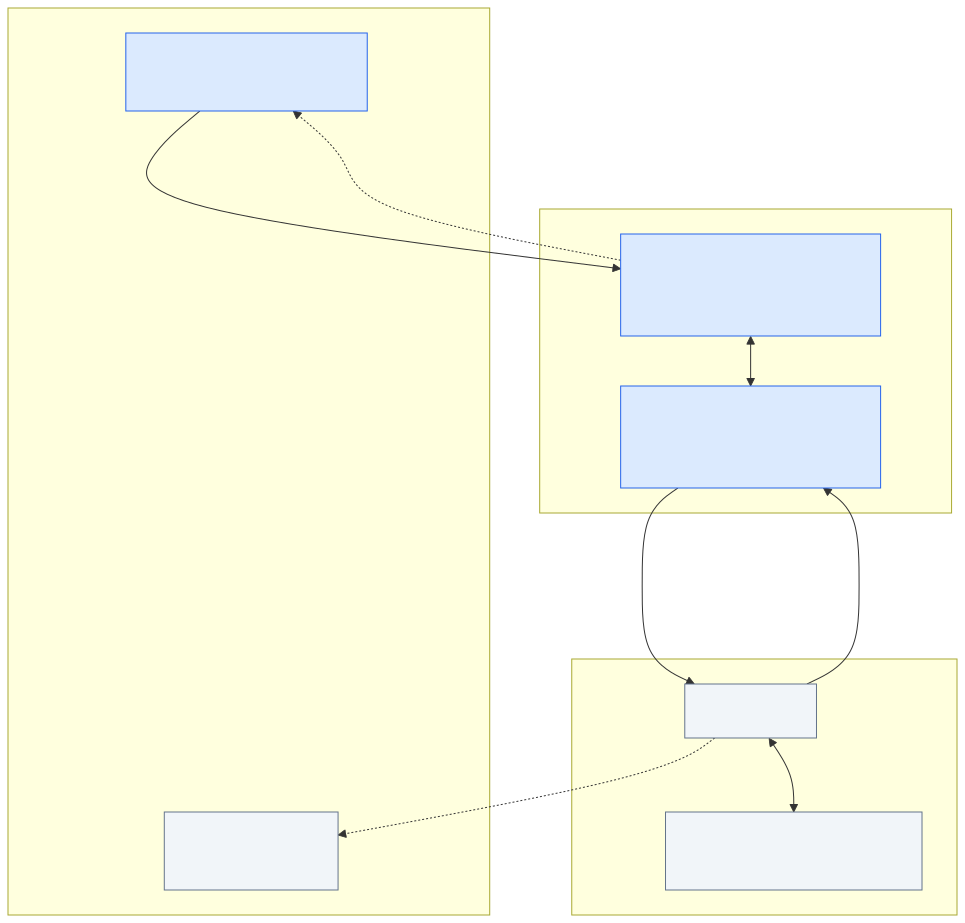

In [4]:
# Deployment view: the two processes, the browser, and every wire between them.
mermaid('''
flowchart TB
    subgraph BROWSER["Your browser - two tabs, side by side"]
        UI["firelab control panel<br/>Svelte 5, one $state store"]
        V3D["BuildSim viewer<br/>the 3D building"]
    end

    subgraph P1["Process 1: firelab - Python, uvicorn on :8090"]
        API["app/main.py + app/api/<br/>FastAPI: REST + SSE + static files"]
        ENG["app/engine/<br/>the tick loop and all mutable state"]
        API <--> ENG
    end

    subgraph P2["Process 2: BuildSim - Go, Gin on :9090"]
        BAPI["REST API"]
        BST["floor plans, walkable graph,<br/>equipment, viewer sessions"]
        BAPI <--> BST
    end

    UI -- "REST: every button press" --> API
    API -. "SSE /api/events: one snapshot per publish" .-> UI
    ENG -- "REST: layers, effects, alerts, doors,<br/>entities, occupancy, highlights, routes" --> BAPI
    BAPI -- "floor plans, walkable routes" --> ENG
    BAPI -. "live scene updates" .-> V3D

    classDef mine fill:#dbeafe,stroke:#2563eb
    classDef theirs fill:#f1f5f9,stroke:#64748b
    class API,ENG,UI mine
    class BAPI,BST,V3D theirs
''')


### 2.3 The module view — who may import whom

When one Python file uses code from another it **imports** it, and that creates a
dependency: the importing file now cannot work without the imported one. Left
unmanaged, every file ends up depending on every other, and nothing can be
tested or replaced on its own.

So there is one rule about which direction imports are allowed to point:

> `app` → `adapters` → `domain`, never the other way.

Read it as: the layer that deals with the outside world is allowed to know about
the rules of fire, but the rules of fire are not allowed to know that a network
exists.

In the diagram below, **no arrow ever points upward**. Green boxes import
nothing outside the standard library — no clock, no network, no BuildSim. That
is why `make test` runs with nothing else up, and why every green module is a
plain function you can call from a cell in this notebook.

The layers are not equal in kind. Each exists to hold something the others must
not have:

| Layer | Holds | Must not have |
|---|---|---|
| `domain/` | rules, physics, decisions | state that outlives a call, I/O, the time of day |
| `adapters/` | knowledge of BuildSim's URLs and payload shapes | any opinion about fire |
| `app/` | all mutable state, the loop, the wall clock | any rule you would want to unit-test |

#### What holds the state

Everything mutable lives on the single `Engine` instance. This is the inventory,
and it is worth knowing because every panel in the UI is a view of one of these:

| Field | What it is |
|---|---|
| `world` | the `Space` per room and the `Coupling` per doorway — the truth |
| `sources` | what is currently burning, each with its ground-truth label |
| `devices` | every deployed sensor, with its own lag, drift and fault |
| `windows` | the last 120 s of readings per room — all the detector may see |
| `features`, `probabilities` | this tick's derived values, one entry per monitored room |

| `agents` | one `RoomAgent` per room, holding its alarm state and dwell timers |

| `occupants` | every person, their position and their remaining route |snapshot for the UI.

| `doors` | open or closed, per room |clearing these fields, and what lets the whole simulation be serialised into one

| `score`, `history`, `journal` | the run's marks, its time series, and its audit log |Nothing else in the codebase owns state. That is what makes a reset a matter of


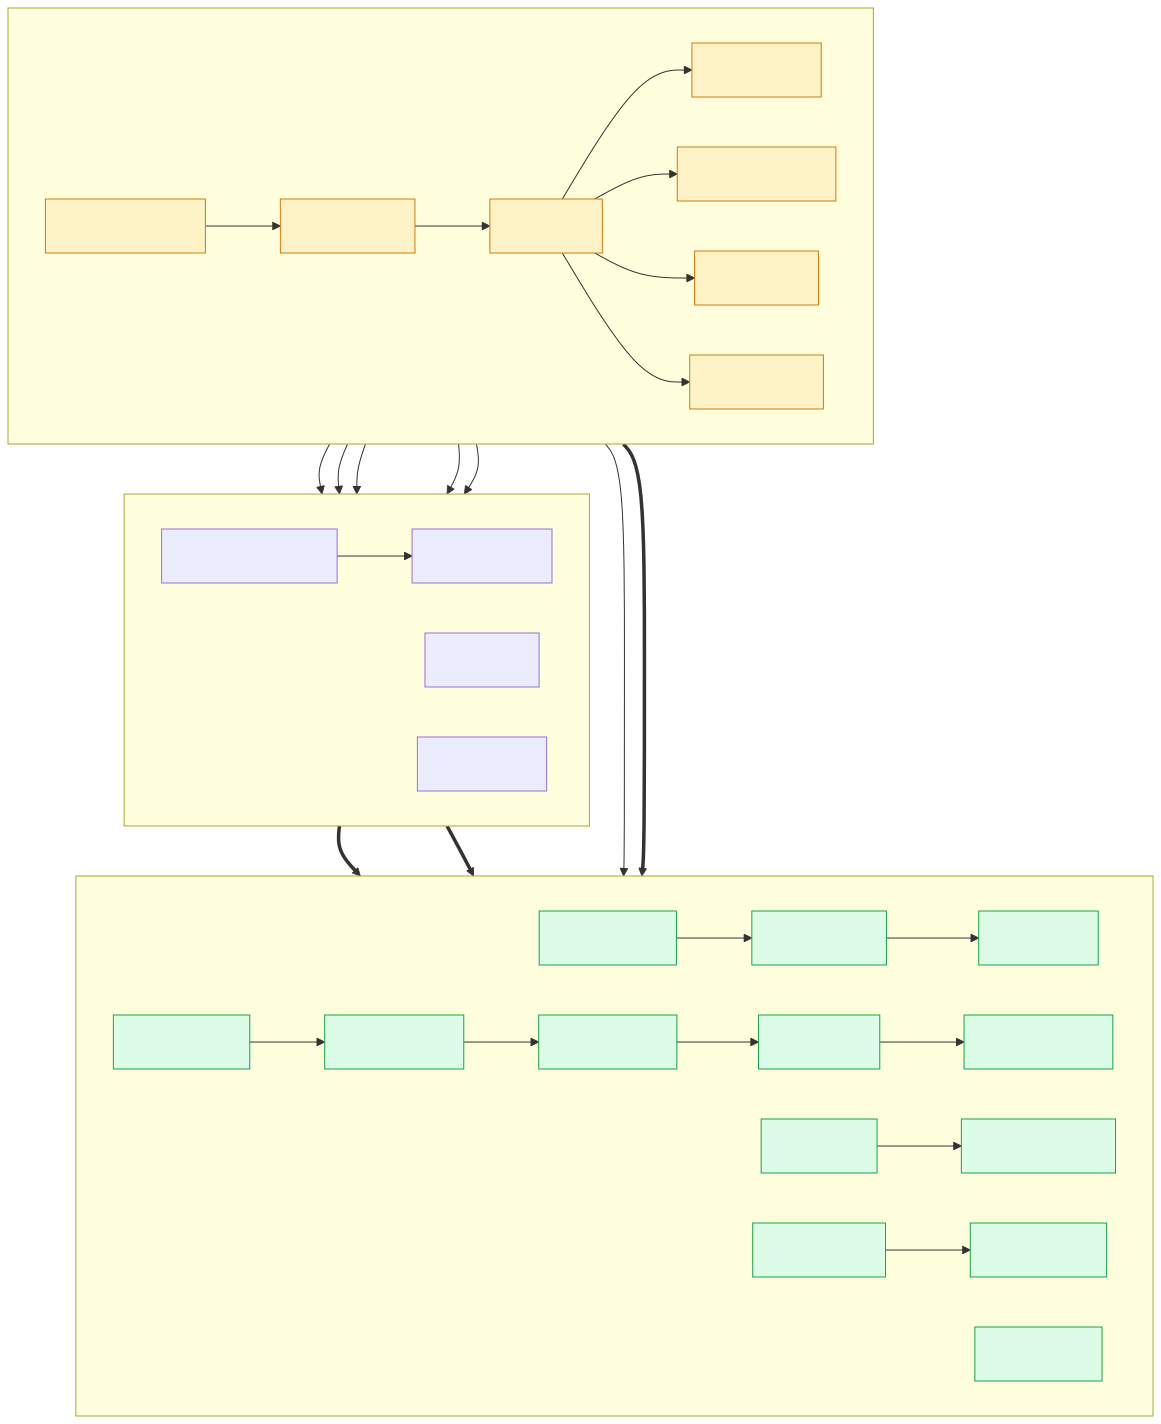

In [5]:
# Module view: every arrow drawn is a real import, though only the structural
# ones are shown. Nothing green ever points back up at yellow.
mermaid('''
flowchart TB
    subgraph APP["app/ - impure: mutable state, the wall clock, HTTP"]
        direction LR
        MAIN["main.py + api/"] --> RT["runtime.py"]
        RT --> ENGINE["engine/"]
        ENGINE --> SNAP["snapshot/"]
        ENGINE --> EVAC["evacuation.py"]
        ENGINE --> CFG["config.py"]
        ENGINE --> PRE["presets.py"]
    end

    subgraph ADP["adapters/ - the only code that knows BuildSim exists"]
        direction LR
        WB["world_builder.py"] --> CLIENT["buildsim.py"]
        EXI["exits.py"]
        PUB["publisher/"]
    end

    subgraph DOM["domain/ - pure: stdlib only, no clock, no network"]
        direction LR
        SRC["sources.py"] --> PHYS["physics.py"]
        PHYS --> WRLD["world.py"]
        SENS["sensing.py"] --> FEAT["features.py"]
        FEAT --> DETE["detector.py"]
        DETE --> AGEN["agent.py"]
        AGEN --> LOCK["interlocks.py"]
        ROLE["roles.py"] --> OCC["occupants.py"]
        SCO["scoring.py"] --> TIME["timeline.py"]
        HIST["history.py"]
    end

    ENGINE --> WB
    ENGINE --> EXI
    ENGINE --> PUB
    ENGINE --> CLIENT
    EVAC --> CLIENT
    EVAC --> OCC
    ENGINE ==> DOM
    PUB ==> DOM
    WB ==> WRLD

    classDef pure fill:#dcfce7,stroke:#16a34a
    classDef edge fill:#fef3c7,stroke:#d97706
    class SRC,PHYS,WRLD,SENS,FEAT,DETE,AGEN,LOCK,ROLE,OCC,SCO,TIME,HIST pure
    class MAIN,RT,ENGINE,SNAP,EVAC,CFG,PRE edge
''')


### 2.4 The front-end view — one store, one direction

The **front end** is the control panel you click on, running inside your browser.
It is written in Svelte, which builds a page out of small reusable pieces called
**components** — one per panel. A **store** is a single shared object that every
component can read.

The design here is deliberately boring: there is exactly one store, the server
fills it, and no component is allowed to compute anything of its own.

The control panel is Svelte 5 with runes, built by Vite into `ui/dist` and
served by FastAPI at `/`. There is no router, no component library and no
charting dependency — the charts are hand-rolled inline SVG.

The whole design lives in one short file, `ui/src/lib/store.svelte.js`:

```js
export const store = $state({
  snapshot: null,   // the entire simulation, replaced wholesale on every event
  rooms: [],        // the room list, fetched once at start-up
  presets: [],      // the scenario catalogue, fetched once
  config: null,     // current thresholds and settings
  live: false,      // is the SSE stream still connected
  error: ''         // last failed request, shown in the header
});
```

`bootstrap()` fetches the three static lists once, then opens an `EventSource`
on `/api/events` and assigns each message straight into `store.snapshot`.
Because `store` is a `$state` rune, **every component that reads it re-renders
by itself**. No component subscribes, no component keeps its own copy, and
there is no polling loop anywhere — except `RoomDetail`, which asks
`/api/history` for the one selected room.

That gives a strictly one-way cycle:

> SSE → `store.snapshot` → components render → user clicks → `api.*` → REST →
> the engine changes → next snapshot

Nothing in the UI ever computes simulation state. If a number is on screen, the
server sent it. This is the front-end counterpart of the backend's dependency
rule: the panels are as passive as `domain/` is pure.

Commands go out through a single `call()` wrapper, so there is exactly one
place where a failed request is turned into `store.error` and one place where
the header's error strip gets its text.

| Component | Slice of state it reads | Commands it sends |
|---|---|---|
| `App.svelte` | — | — (owns `selected`, the only local state) |
| `Header` | `clock`, `buildsim`, `live` | `clock`, `reset`, `reload` |
| `ScenarioPanel` | `sources`, `presets` | `ignite`, `preset`, `extinguish` |
| `Scorecard` | `score` | — |
| `EvacuationPanel` | `evacuation` | — |
| `TenabilityPanel` | `tenability` | — |
| `SensorPanel` | `rooms` | `deploy`, `undeploy` |
| `PopulationPanel` | `population`, `roles` | `putPopulation` |
| `SettingsPanel` | `config` | `putConfig` |
| `RoomTable` | `spaces` | — (pure table; the expanded row is `DeviceList`) |
| `DeviceList` | `space.devices` passed in as a prop | `fault` |
| `RoomDetail` / `Chart` | `/api/history` for one room | — |

| `ResponsePanel` | `counts`, `auto`, `config` | `command`, `mode`, `putConfig` |

| `Journal` | `journal` | — |precisely which components break.

| `RoomPicker` | `rooms` | — (shared picker widget) |`app/snapshot/` output each panel depends on. Change a key there and you know

Read the middle column as a contract: it is exactly the part of the

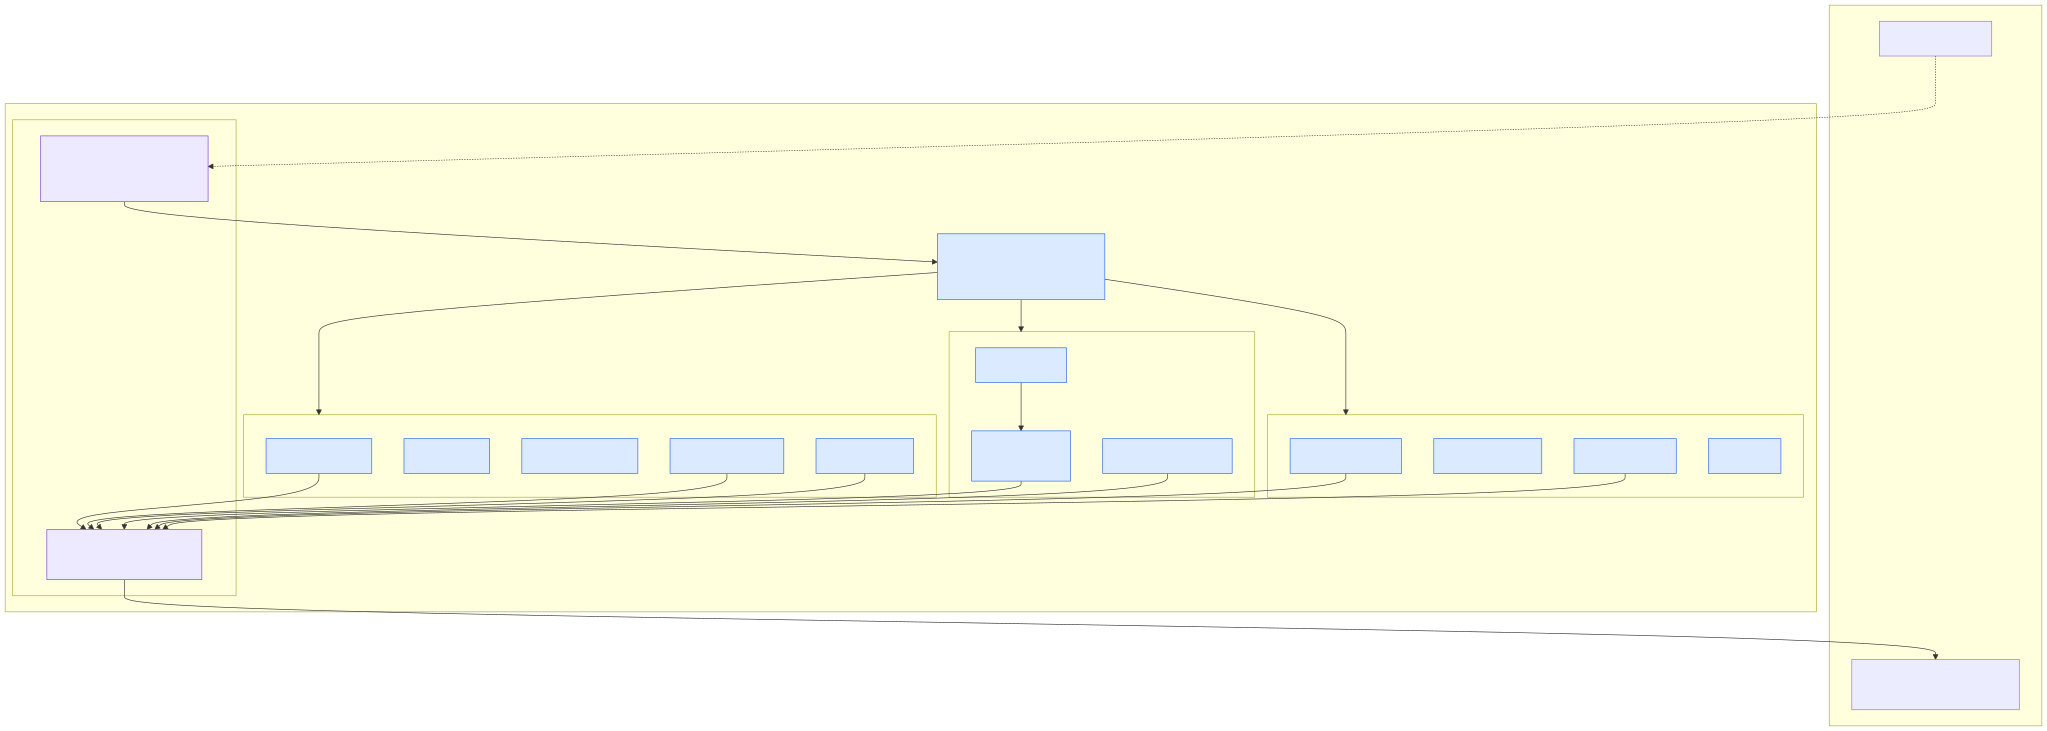

In [6]:
# Front-end view: state flows down one path only, commands leave by another.
# Purple is the only mutable thing in the browser; every blue box is a pure view of it.
mermaid('''
flowchart TB
    subgraph SERVER["firelab, :8090"]
        SSE["GET /api/events"]
        REST["POST / PUT / DELETE /api/*"]
    end

    subgraph BUNDLE["ui/dist - built by Vite, served by FastAPI at /"]
        subgraph STORE["lib/store.svelte.js - the only state in the front end"]
            ST["store = $state<br/>snapshot, rooms, presets, config, live, error"]
            APIF["api.*<br/>one function per endpoint"]
        end

        APP["App.svelte<br/>three-column layout, owns 'selected'"]

        subgraph LEFT["left column - set up the run"]
            SCEN["ScenarioPanel"]
            SCORE["Scorecard"]
            EVACP["EvacuationPanel"]
            POPP["PopulationPanel"]
            SENSP["SensorPanel"]
        end
        subgraph MID["centre column - watch the run"]
            TABLE["RoomTable"]
            DEV["DeviceList<br/>fault injection"]
            DETAIL["RoomDetail + Chart"]
            TABLE --> DEV
        end
        subgraph RIGHT["right column - act and audit"]
            RESP["ResponsePanel"]
            TEN["TenabilityPanel"]
            SET["SettingsPanel"]
            JOUR["Journal"]
        end
    end

    SSE -. "one snapshot per publish" .-> ST
    ST --> APP
    APP --> LEFT
    APP --> MID
    APP --> RIGHT
    SCEN --> APIF
    SENSP --> APIF
    POPP --> APIF
    DEV --> APIF
    DETAIL --> APIF
    RESP --> APIF
    SET --> APIF
    APIF -- "fetch" --> REST

    classDef state fill:#ede9fe,stroke:#7c3aed
    classDef view fill:#dbeafe,stroke:#2563eb
    class ST,APIF state
    class SCEN,SCORE,EVACP,POPP,SENSP,TABLE,DEV,DETAIL,RESP,TEN,SET,JOUR,APP view
''')


## 3. `domain/` — the pure core

Everything below is standard library only, so these cells run on any Python
kernel without firelab's virtualenv. Each module is small enough to read in one
sitting; the helper prints the real source from disk.

In [7]:
import inspect
import textwrap

from IPython.display import Code

# These modules are plain Python with no external libraries, so importing them
# here costs nothing and needs no services running.
from firelab.domain import agent, detector, features, history, interlocks
from firelab.domain import occupants, physics, roles, scoring, sensing
from firelab.domain import sources, timeline, world


def show(obj):
    """Print the real code of a function or class, syntax-highlighted.

    `inspect.getsource` reads it back from the file on disk, so what you see
    below is always the code that actually runs — it can never go out of date.
    """
    return Code(textwrap.dedent(inspect.getsource(obj)), language='python')


def extract(relative_path, first_line, stop_line):
    """Show one chunk of a file without importing it.

    Used for modules that need libraries this notebook's kernel may not have.
    It reads the file as text and cuts out everything between the two markers.
    """
    text = (ROOT / relative_path).read_text()
    start = text.index(first_line)
    return Code(text[start:text.index(stop_line, start)].rstrip(), language='python')


print('imported the whole domain with no services running')


imported the whole domain with no services running


### 3.1 `sources.py` — what is burning

A `Source` is an ignition event with a **kind**, and the kind does double duty:
it sets the emission signature *and* it is the ground-truth label the scorecard
grades against.

| kind | heat | smoke | CO | real fire? |
|---|---|---|---|---|
| `flaming` | high, t² growth | high | moderate | yes |
| `smouldering` | almost none | dense | **very high** | yes |
| `cooking` | mild | moderate | low | no — nuisance |
| `dust` | none | moderate | none | no — nuisance |
| `steam` | none | moderate | none | no — nuisance |

The smouldering row is the whole reason CO is sensed. A smoke detector alone
cannot tell it from burnt toast; the CO-to-smoke ratio can.

Flaming fires follow the standard t² growth curve, `Q = alpha * t^2`, with the
four NFPA growth rates.

In [8]:
# ALPHA: how fast a flaming fire grows. KINDS: the five things that can be lit.
print('ALPHA =', sources.ALPHA)
print('KINDS =', sources.KINDS)

# emission(source, now) answers: at this moment, how much heat, smoke and CO is
# this source putting out? One branch per kind — that is the whole fire model.
show(sources.emission)


ALPHA = {'slow': 0.0029, 'medium': 0.0117, 'fast': 0.0469, 'ultrafast': 0.1876}
KINDS = ('flaming', 'smouldering', 'cooking', 'dust', 'steam')


def emission(source: Source, now: float) -> tuple[float, float, float]:
    """Return (heat_kW, smoke_equilibrium_1/m, co_equilibrium_ppm) at `now`.

    Equilibrium form keeps each source to a few lines and leaves the lag to the
    room. The CO-to-smoke ratio is what separates a fire from a nuisance.
    """
    e = now - source.t_start  # seconds since ignition
    if e <= 0:
        return 0.0, 0.0, 0.0  # not lit yet

    if source.kind == "flaming":
        # Heat grows with the square of time until it runs out of fuel.
        heat = min(ALPHA.get(source.growth, ALPHA["medium"]) * e * e, source.peak_kw)
        return heat, 0.06 * heat**0.5, 4.0 * heat**0.5

    if source.kind == "smouldering":
        # Barely any heat, dense smoke, very high CO: the hard case.
        ramp = 1 - exp(-e / 300)
        return 3.0 * ramp, 0.9 * ramp, 900.0 * ramp

    if source.kind == "cooking":
        # Warm and smoky, but hardly any CO: burnt toast, not a fire.
        ramp = _bump(e, 180, 900)
        return 12.0 * ramp, 0.35 * ramp, 25.0 * ramp

    if source.kind == "dust":
        # Smoke alone: no heat, no CO. A smoke detector on its own is fooled.
        return 0.0, 0.5 * _bump(e, 20, 120), 0.0

    if source.kind == "steam":
        return 0.0, 0.7 * _bump(e, 30, 200), 0.0

    return 0.0, 0.0, 0.0  # unknown kind: emit nothing

### 3.2 `world.py` and `physics.py` — the building and the solver

`world.py` holds the nouns: `Space` (one room or corridor), `Coupling` (a
door-gated opening between two of them) and `World` (all of both). Ten modules
import `World` or `Space` without ever running the solver, which is why the two
are separate files.

`physics.py` holds the verbs. One lumped node per room. Three state variables —
temperature, smoke, CO — each relaxing towards a target with a first-order lag,
plus diffusion along the couplings between rooms.


In [9]:
# The tuning constants of the world model: outdoor temperature, how quickly each
# quantity responds (tau), how much leaks between rooms, and the safety caps.
for name in ['T_OUT', 'TAU_TEMP', 'TAU_SMOKE', 'TAU_CO', 'DIFFUSION_SMOKE',
             'SPRINKLER_HRR_FACTOR', 'TEMP_GAIN', 'TEMP_CEILING']:
    print(f'{name:<22} {getattr(physics, name)}')

# step(world, emissions, dt) advances every room by dt seconds: add what the
# fires emit, let each value drift towards its target, then spread to neighbours.
show(physics.step)


T_OUT                  20.0
TAU_TEMP               90.0
TAU_SMOKE              45.0
TAU_CO                 60.0
DIFFUSION_SMOKE        0.35
SPRINKLER_HRR_FACTOR   0.25
TEMP_GAIN              140.0
TEMP_CEILING           900.0


def step(world: World, emissions: dict[str, tuple[float, float, float]], dt: float) -> None:
    """Advance every space by `dt` seconds given this tick's source emissions.

    Two phases: first each room reacts to whatever is burning inside it, then
    neighbouring rooms trade some of what they have through the doorways.
    """
    for key, space in world.spaces.items():
        # Where this room is heading, given what is burning in it right now.
        heat, smoke_eq, co_eq = emissions.get(key, (0.0, 0.0, 0.0))
        if space.sprinkler:
            heat *= SPRINKLER_HRR_FACTOR
            smoke_eq *= SPRINKLER_SMOKE_WASHOUT

        # Sub-linear rise with heat density, capped at flashover temperatures.
        temp_target = T_OUT + min(TEMP_GAIN * (heat / space.volume_m3) ** (2 / 3), TEMP_CEILING)

        # Nothing jumps: each value eases towards its target at its own pace.
        space.temperature = approach(space.temperature, temp_target, TAU_TEMP, dt)
        space.smoke = approach(space.smoke, smoke_eq, TAU_SMOKE, dt)
        space.co = approach(space.co, co_eq, TAU_CO, dt)

    _diffuse(world, dt)

### 3.3 `sensing.py` — how the truth gets spoiled

A device is a chain applied in a fixed order:

```
lag  ->  bias  ->  noise  ->  quantisation  ->  clamp  ->  fault
```

Order matters. Quantising before adding noise would hide the noise; clamping
before the fault would let a dead sensor report a plausible value.

Five fault modes, all selectable per device from the UI:

| fault | behaviour | why it matters |
|---|---|---|
| `none` | healthy | baseline |
| `stuck` | repeats its last reading forever | looks alive, says nothing |
| `dropout` | intermittently returns nothing | gaps in the feature window |
| `drift` | slowly wanders upward | the classic false-alarm cause |
| `dead` | returns nothing at all | tests whether the other modalities carry it |

Each modality has its own lag, noise floor and resolution. Temperature is slow
(tau 30 s) because a real heat detector has thermal mass; smoke is fast.

In [10]:
print('MODALITIES =', sensing.MODALITIES)  # what a sensor can measure
print('FAULTS     =', sensing.FAULTS)      # the ways one can misbehave
print()

# Each modality has its own imperfections: how sluggish it is (tau), a constant
# offset (bias), random jitter (noise), its resolution (quantum) and its range.
print(f"{'modality':<12} {'tau':>6} {'bias':>6} {'noise':>7} {'quantum':>8} {'low':>7} {'high':>8}")
for modality, spec in sensing.DEFAULTS.items():
    tau, bias, noise, quantum, low, high = spec
    print(f'{modality:<12} {tau:>6} {bias:>6} {noise:>7} {quantum:>8} {low:>7} {high:>8}')

# sample(...) takes the true value and returns what the sensor claims to see,
# applying those imperfections in order and then any fault.
show(sensing.sample)


MODALITIES = ('smoke', 'co', 'temperature')
FAULTS     = ('none', 'stuck', 'dropout', 'drift', 'dead')

modality        tau   bias   noise  quantum     low     high
smoke          12.0    0.0    0.01    0.005     0.0      3.0
co             25.0    0.0     3.0      1.0     0.0   2000.0
temperature    30.0    0.0    0.15      0.1   -20.0    250.0


def sample(device: Device, truth: float, now: float, dt: float, rng: Random) -> float | None:
    """Advance the device and return a new reading, or None between samples.

    This is the only place the true value is turned into an observation, and it
    is where every one of the system's blind spots comes from.
    """
    # The element always tracks reality, but lags behind it.
    device.internal = approach(device.internal, truth, max(device.tau, 1e-3), dt)

    # Real detectors report every few seconds, not continuously.
    if now < device.next_sample:
        return None
    device.next_sample = now + max(device.interval, 1.0)

    if device.fault == "dead":
        device.reading = None
        return None  # says nothing, ever
    if device.fault == "dropout" and rng.random() < 0.4:
        return None  # skips this reading at random
    if device.fault == "stuck":
        # Repeats its last value forever: looks alive, reports nothing new.
        value = device.reading if device.reading is not None else device.internal
        device.reading = value
        _remember(device, now, value)
        return value
    if device.fault == "drift":
        # Wanders upward a little more each reading. The classic false alarm.
        device.drift += 0.02 * (device.high - device.low) / 600.0 * device.interval

    # The healthy path: offset, then jitter, then rounding, then the sensor range.
    value = device.internal + device.bias + device.drift
    value += rng.gauss(0.0, device.noise)
    if device.quantum > 0:
        value = round(value / device.quantum) * device.quantum
    value = min(max(value, device.low), device.high)

    device.reading = value
    _remember(device, now, value)
    return value

### 3.4 `features.py` — what the detector is allowed to see

This is the firewall. `extract` takes a `Window` of *readings* and produces a
feature vector. It is never handed a `Space`, so it cannot cheat.

Seven features over a 120-second window:

| feature | meaning | discriminates |
|---|---|---|
| `smoke`, `co`, `temperature` | latest reading | magnitude |
| `smoke_rate` | d(smoke)/dt | a fire accelerates, dust does not |
| `temperature_rise` | above baseline | flaming vs smouldering |
| `co_smoke_ratio` | CO per unit smoke | **smouldering vs cooking or dust** |
| `neighbour_agreement` | do adjacent rooms see smoke too | real smoke spreads, a faulty sensor does not |
| `coverage` | how many modalities reported | how much to trust the rest |

`co_smoke_ratio` is gated: below a floor of smoke it is forced to zero, otherwise
dividing near-zero by near-zero produces enormous meaningless ratios.

That gate is also why `co` is scored on its own and not only through the ratio.
A dead smoke detector sends `smoke` to zero, which closes the gate and takes the
whole CO pathway down with it — so the one modality that was meant to save the
room falls silent exactly when it is needed. Watch for this shape of bug: a
feature that is *conditioned on* another feature inherits that feature's faults.


In [11]:
# How far back the detector is allowed to look, in seconds.
print('WINDOW_SECONDS =', features.WINDOW_SECONDS)

# extract(window, ...) boils two minutes of noisy readings down to a handful of
# numbers. Note the arguments: readings only, never the simulated truth.
show(features.extract)


WINDOW_SECONDS = 120.0


def extract(window: Window, neighbour_smoke: list[float], baseline: float = 20.0) -> Features:
    """Turn two minutes of readings into the handful of numbers the detector uses.

    Note the arguments: a window of readings and the neighbours' smoke levels.
    The true state of the room is deliberately not available here.
    """
    smoke = window.latest("smoke")
    co = window.latest("co")
    temperature = window.latest("temperature", baseline)

    # Real smoke spreads next door; a faulty sensor is alone in what it sees.
    agreement = 0.0
    if neighbour_smoke:
        raised = sum(1 for value in neighbour_smoke if value > 0.05)
        agreement = raised / len(neighbour_smoke)

    return Features(
        space=window.space,
        smoke=smoke,
        co=co,
        temperature=temperature,
        smoke_rate=window.rate_per_minute("smoke"),
        temperature_rise=max(0.0, temperature - baseline),
        # Below a little smoke the ratio is meaningless, so force it to zero.
        co_smoke_ratio=co / smoke if smoke > 0.05 else 0.0,
        neighbour_agreement=agreement,
        # How many of the three sensors are working: how much to trust the rest.
        coverage=len([m for m in ("smoke", "co", "temperature") if window.series.get(m)]),
    )

### 3.5 `detector.py` — the seam

`Detector` is a `Protocol` with three members: `name`, `probability(features)`
and `explain(features)`. The shipped implementation is `FusionRule`, a weighted
logistic sum. Anything satisfying the protocol — a gradient-boosted tree, a small
neural net — drops straight in.

`explain` is not decoration. `probability` is *defined* as the logistic of the
sum of the terms `explain` returns, so the bars in the UI cannot disagree with
the number they explain. That is the difference between an explanation and a
plausible story.

Two details worth knowing:

- **CO twice over.** There is a term for the CO reading itself and another for
  the CO-to-smoke ratio. The ratio is the sharper discriminator — a smouldering
  fire has a huge one, burnt toast has almost none — but it is a fraction with
  smoke underneath it, so it goes silent the moment the smoke sensor dies. The
  absolute term is what still speaks when that happens. Without it a fully
  developed fire with a dead smoke detector scores below the *investigate*
  threshold: the detector never even looks.
- **`ratio_gate`** scales the CO-ratio term down when there is barely any smoke,
  so a room with a whiff of CO and no smoke does not flap into alarm.
- **coverage confidence**: the result is multiplied by
  `0.55 + 0.45 * min(coverage, 3) / 3`. One working sensor can never reach the
  confirm threshold on its own.

In [12]:
# FusionRule turns features into a probability. explain() lists each feature's
# contribution; probability() is just those contributions added up and squashed
# into the 0-1 range by the logistic function.
show(detector.FusionRule)


class FusionRule:
    """Hand-written multi-modal baseline. The model has to beat this."""

    name = "fusion-rule"

    def __init__(self, weights: dict[str, float] | None = None) -> None:
        # How much each piece of evidence counts. `bias` is negative: the room is
        # assumed to be fine until the evidence outweighs it.
        self.weights = weights or {
            "smoke": 3.2,
            "co": 1.8,
            "co_smoke_ratio": 1.6,
            "temperature_rise": 0.55,
            "smoke_rate": 1.4,
            "neighbour_agreement": 0.8,
            "bias": -3.4,
        }

    def explain(self, features: Features) -> list[Contribution]:
        """Score each piece of evidence separately. Their sum is the raw score.

        The UI draws these as bars, so the explanation is the calculation rather
        than a story told about it afterwards.
        """
        w = self.weights
        # The CO/smoke ratio is only meaningful once there is smoke to divide by.
        ratio_gate = min(features.smoke / 0.15, 1.0)
        # Normalised so no single modality can saturate the sum on its own.
        return [
            Contribution("bias", 1.0, w["bias"]),
            Contribution("smoke", features.smoke, w["smoke"] * min(features.smoke, 1.5)),
            # CO on its own, not divided by anything: this is the only term that
            # still speaks when the smoke detector is dead. Cooking peaks at about
            # 25 ppm, so that is where the evidence is taken to start.
            Contribution(
                "co", features.co, w["co"] * min(max(features.co - 25.0, 0.0) / 125.0, 1.0)
            ),
            Contribution(
                "co_smoke_ratio",
                features.co_smoke_ratio,
                w["co_smoke_ratio"] * min(features.co_smoke_ratio / 250.0, 2.5) * ratio_gate,
            ),
            Contribution(
                "temperature_rise",
                features.temperature_rise,
                # Clipped at 60 rather than 40 so a serious fire can be carried by
                # heat alone. Nuisances never get near either number.
                w["temperature_rise"] * min(features.temperature_rise, 60.0) / 10.0,
            ),
            Contribution(
                "smoke_rate",
                features.smoke_rate,
                w["smoke_rate"] * min(max(features.smoke_rate, 0.0), 1.0),
            ),
            Contribution(
                "neighbour_agreement",
                features.neighbour_agreement,
                w["neighbour_agreement"] * features.neighbour_agreement,
            ),
        ]

    def probability(self, features: Features) -> float:
        """Add up the contributions and turn the total into a 0..1 probability."""
        if features.coverage == 0:
            return 0.0  # no working sensor: no opinion, not a low probability
        score = sum(term.weighted for term in self.explain(features))
        # Fewer working sensors means less confidence, so the score is held back.
        # With only one modality it can never reach the confirm threshold.
        confidence = min(features.coverage, 3) / 3.0
        return _logistic(score) * (0.55 + 0.45 * confidence)

In [13]:
# Four hand-written feature vectors: this is the whole design problem in one cell.
# Two are real fires, two are nuisances, and all four have plenty of smoke.
rule = detector.FusionRule()

cases = {
    'flaming fire': dict(smoke=0.60, co=140.0, temperature=95.0, smoke_rate=0.05,
                         temperature_rise=75.0, co_smoke_ratio=233.0,
                         neighbour_agreement=0.8, coverage=3),
    'smouldering':  dict(smoke=0.45, co=520.0, temperature=24.0, smoke_rate=0.01,
                         temperature_rise=4.0, co_smoke_ratio=1155.0,
                         neighbour_agreement=0.4, coverage=3),
    'burnt toast':  dict(smoke=0.40, co=12.0, temperature=27.0, smoke_rate=0.03,
                         temperature_rise=7.0, co_smoke_ratio=30.0,
                         neighbour_agreement=0.2, coverage=3),
    'dust cloud':   dict(smoke=0.35, co=0.0, temperature=20.5, smoke_rate=0.04,
                         temperature_rise=0.5, co_smoke_ratio=0.0,
                         neighbour_agreement=0.0, coverage=3),
}

# Print the score and the reasons behind it. Heat gives the flaming fire away,
# the CO ratio gives the smouldering one away; the nuisances score low on both.
for label, values in cases.items():
    vector = features.Features(space='demo', **values)
    terms = rule.explain(vector)
    detail = '  '.join(f'{t.name}={t.weighted:+.2f}' for t in terms)
    print(f'{label:<14} P(fire)={rule.probability(vector):.2f}')
    print(f'{"":<14} {detail}')


flaming fire   P(fire)=1.00
               bias=-3.40  smoke=+1.92  co=+1.66  co_smoke_ratio=+1.49  temperature_rise=+3.30  smoke_rate=+0.07  neighbour_agreement=+0.64
smouldering    P(fire)=0.99
               bias=-3.40  smoke=+1.44  co=+1.80  co_smoke_ratio=+4.00  temperature_rise=+0.22  smoke_rate=+0.01  neighbour_agreement=+0.32
burnt toast    P(fire)=0.21
               bias=-3.40  smoke=+1.28  co=+0.00  co_smoke_ratio=+0.19  temperature_rise=+0.39  smoke_rate=+0.04  neighbour_agreement=+0.16
dust cloud     P(fire)=0.10
               bias=-3.40  smoke=+1.12  co=+0.00  co_smoke_ratio=+0.00  temperature_rise=+0.03  smoke_rate=+0.06  neighbour_agreement=+0.00


### 3.6 `agent.py` — the alarm state machine

One agent per room. A probability alone is not a decision; a decision needs
hysteresis, or a sensor flickering across a threshold would open and close fire
doors all day.

```
NORMAL -> INVESTIGATING -> PRE_ALARM -> CONFIRMED -> CLEARING -> NORMAL
                                            |
                                            +-> SUPPRESSED (sprinkler holding it)
```

Each upward transition needs the probability to stay above its threshold for a
**dwell time**, and clearing needs 90 seconds below the clear threshold. The
thresholds and dwells are live-editable from the response panel.

The agent emits `Command` objects and never writes to BuildSim itself, which is
what keeps the decision logic pure and testable.

A command it emits stays on its list until something carries it out. This matters
more than it sounds: an interlock refusing water in a cold room is saying *not
yet*, not *no*. A request made once, at the instant of a state change, would be
lost for the rest of the run the first time the answer was no — and the answer is
always no at that instant, because a room that has just confirmed is still full of
the people the door interlock exists to protect.


In [14]:
# The trigger levels, and how long the probability must stay there (the dwells).
print(agent.Thresholds())

# update(...) is called once per room per tick: compare P(fire) to the
# thresholds, move the room to its next state, and return any commands to send.
show(agent.update)


Thresholds(investigate=0.35, pre_alarm=0.55, confirm=0.75, clear=0.25, dwell_pre_alarm=20.0, dwell_confirm=25.0, dwell_clear=90.0)


def update(
    agent: RoomAgent, probability: float, now: float, thresholds: Thresholds
) -> list[Command]:
    """Advance one room's state machine and return the commands it wants issued."""
    agent.probability = probability

    # Keep track of how long the probability has been high, and how long low.
    # Setting the timestamp to None resets the stopwatch.
    if probability >= thresholds.pre_alarm:
        agent.above_since = agent.above_since if agent.above_since is not None else now
    else:
        agent.above_since = None
    if probability <= thresholds.clear:
        agent.below_since = agent.below_since if agent.below_since is not None else now
    else:
        agent.below_since = None
    if probability < thresholds.confirm:
        agent.under_since = agent.under_since if agent.under_since is not None else now
    else:
        agent.under_since = None

    previous = agent.state

    # One step at a time, and only ever to a neighbouring state.
    if agent.state in ("NORMAL", "CLEARING"):
        if probability >= thresholds.investigate:
            agent.state = "INVESTIGATING"
        elif agent.state == "CLEARING" and now - agent.since >= thresholds.dwell_clear:
            # Quiet ever since it stood down, so stop flagging the room as an incident.
            agent.state = "NORMAL"
    elif agent.state == "INVESTIGATING":
        if agent.above_since is not None and now - agent.above_since >= thresholds.dwell_pre_alarm:
            agent.state = "PRE_ALARM"
        elif probability < thresholds.clear:
            agent.state = "NORMAL"
    elif agent.state == "PRE_ALARM":
        if probability >= thresholds.confirm and now - agent.since >= thresholds.dwell_confirm:
            agent.state = "CONFIRMED"
        elif probability < thresholds.investigate:
            agent.state = "INVESTIGATING"
    elif agent.state == "CONFIRMED":
        # Standing down takes much longer than raising the alarm did.
        if agent.below_since is not None and now - agent.below_since >= thresholds.dwell_clear:
            agent.state = "CLEARING"
        elif (
            agent.suppressing
            and agent.under_since is not None
            and now - agent.under_since >= thresholds.dwell_confirm
        ):
            # Water has been on the fire and the evidence has stayed down for as
            # long as it took to confirm: the fire is being held, not out.
            agent.state = "SUPPRESSED"
    elif agent.state == "SUPPRESSED":
        if agent.below_since is not None and now - agent.below_since >= thresholds.dwell_clear:
            agent.state = "CLEARING"
        elif probability >= thresholds.confirm:
            agent.state = "CONFIRMED"  # burning on through the water

    if agent.state != previous:
        agent.since = now
        # SUPPRESSED is still an alarm, so CONFIRMED's outstanding requests stand.
        if agent.state != "SUPPRESSED":
            agent.pending = _on_enter(agent)

    # Anything the interlocks deferred is offered again on every tick.
    return list(agent.pending)

### 3.7 `interlocks.py` — the veto

Every command, whether proposed by the agent or clicked by a human in the manual
override panel, goes through the same check. There is no privileged path.

Three rules, each with a reason it can state:

- A sprinkler will not fire below 35 °C. A smoke-only signal is not enough to
  soak a room; that is how you flood a server room over burnt toast.
- Fire doors are never *locked*. The brief asks for doors to be unlocked on
  alarm, and a locked door in a fire is how people die.
- A door will not close if anyone is behind it or it lies on an escape route.

Containment versus egress is the interesting conflict here, and the interlock
resolves it in favour of egress every time.

In [15]:
# check(command, ...) is the last gate before anything physically moves.
# It returns a Verdict: allowed yes or no, plus the reason it can be shown to a user.
show(interlocks.check)


def check(
    command: Command,
    temperature: float,
    occupants: int,
    on_escape_route: bool,
) -> Verdict:
    """Validate one command against the interlocks.

    Every command passes through here, whether the agent proposed it or a person
    clicked it. There is no way round.
    """
    if command.kind == "sprinkler" and command.value == "on":
        # Smoke on its own is not enough to soak a room: burnt toast would do it.
        if temperature < 35.0:
            return Verdict(False, "no heat corroboration: smoke alone does not release water")
        return Verdict(True, "heat corroborated")

    if command.kind == "fire_door" and command.value in ("closed", "locked"):
        if command.value == "locked":
            return Verdict(False, "fire doors fail unlocked")  # never trap anyone
        # Holding smoke back matters less than letting people out.
        if on_escape_route:
            return Verdict(False, "space is on an active escape route")
        if occupants > 0:
            return Verdict(False, f"{occupants} occupant(s) still inside")
        return Verdict(True, "compartment empty and off-route")

    return Verdict(True, "no interlock applies")

### 3.8 `roles.py`, `occupants.py`, `scoring.py`, `timeline.py`, `history.py`

**`roles.py`** is the cast list: five kinds of person and how well each gets
itself out. The speed differences are about familiarity, not fitness — knowing
where the back stairs are matters more than how fast you can run. It is separate
from `occupants.py` because adding a role and changing how people walk are
different jobs.

**`occupants.py`** places people and walks them. Two details that were bugs
before they were features:

- Every person gets a small random `offset` and keeps it. Without it, everyone
  who reaches the same waypoint stacks on one pixel and BuildSim lays them out in
  a single horizontal row sprawling across the floor plan.
- Rooms BuildSim's walkable graph does not reach are skipped. Thirteen of
  level0's 318 rooms have no graph node, so a person placed there could never be
  given a way out — they showed up as permanently stranded.

**`scoring.py`** answers *was the alarm right?* Every source knows whether it is
a real fire, so the system is marked against itself: time to confirm, nuisances
it fell for, fires it never caught. An alarm in a room with no source is only
counted against the system when no real fire is burning anywhere — otherwise it
is smoke that spread, and the alarm is correct.

**`timeline.py`** answers the other half, *was it in time?* — ignition, first
alarm, building empty, and the RSET gaps between them. A system can be perfectly
accurate and still too slow, which is why the two scorecards are kept apart.

**`history.py`** is a ring buffer per room, sampled every 5 simulated seconds and
capped at 240 points. It feeds the charts and the CSV export.


In [16]:
print('REAL kinds   =', scoring.REAL)          # these count as genuine fires
print('ALARM states =', scoring.ALARM_STATES)  # these count as the system alarming
print('MISS_AFTER   =', scoring.MISS_AFTER, 'seconds')  # unnoticed this long = a miss

# update(...) runs every tick and marks the system's homework: a new alarm is a
# catch or a false alarm, and a fire left unnoticed too long becomes a miss.
# The three evacuation milestones are handed off to Timeline.
show(scoring.Scoreboard.update)


REAL kinds   = ('flaming', 'smouldering')
ALARM states = ('CONFIRMED', 'SUPPRESSED')
MISS_AFTER   = 300.0 seconds


def update(
    self,
    now: float,
    sources: list[Source],
    states: dict[str, str],
    evacuating: int = 0,
    inside: int = 0,
    adjacency: dict[str, set[str]] | None = None,
) -> None:
    """Mark the system's homework for this tick."""
    # Compare with last tick so each alarm is only judged once, when raised.
    alarming = {key for key, state in states.items() if state in ALARM_STATES}
    for space in alarming - self._alarming:  # a newly raised alarm
        self._score_alarm(space, now, sources, adjacency or {})
    self._alarming = alarming

    self.timeline.note_alarm(now, bool(alarming))
    self.timeline.note_ignition([s.t_start for s in sources if s.kind in REAL and s.t_start <= now])
    self.timeline.note_evacuation(now, evacuating, inside)

    # A real fire nobody has confirmed after five minutes counts as missed.
    for source in sources:
        if source.kind not in REAL or source.id in self.detected:
            continue
        if now - source.t_start > MISS_AFTER:
            self.missed.add(source.id)

In [17]:
# The cast: who is in the building, and their share of the walking speed.
for role in roles.ROLES:
    print(f'{role.key:<10} x{role.speed:<5} {role.note}')
print('default mix:', roles.DEFAULT_POPULATION)
print()

# summary() turns the three milestones into the timing half of the scorecard.
print('empty timeline:', timeline.Timeline().summary())
print()

# place(spaces, population, rng) scatters people at the start of a run: skip
# rooms with no way out, skip tiny rooms, then drop each person at a random spot.
show(occupants.place)


student    x1.05  quick, but only know the main entrance
lecturer   x1.0   know the building
staff      x1.0   technical and administrative staff
security   x1.15  drilled on the escape routes
visitor    x0.85  have never been here before
default mix: {'student': 28, 'lecturer': 5, 'staff': 4, 'security': 1, 'visitor': 2}

empty timeline: {'alarm_delay': None, 'rset': None, 'rset_from_alarm': None, 'clearing': False}



def place(spaces: Iterable[Space], population: dict[str, int], rng: Random) -> list[Occupant]:
    """Scatter the given mix of people over the usable rooms.

    Rooms the walkable graph does not reach are skipped: nobody could ever be
    given a way out of them.
    """
    spaces = [s for s in spaces if s.routable]
    # Prefer proper rooms; fall back to anything at all rather than place nobody.
    rooms = [s for s in spaces if s.kind != "corridor" and s.area_m2 > MIN_ROOM_AREA] or spaces
    if not rooms:
        return []
    people = []
    for role in ROLES:
        for number in range(max(int(population.get(role.key, 0)), 0)):
            room = rng.choice(rooms)
            # A small permanent nudge off the room centre. Without it everyone who
            # reaches the same waypoint would be drawn on one spot.
            offset = (
                rng.uniform(-PERSONAL_SPACE, PERSONAL_SPACE),
                rng.uniform(-PERSONAL_SPACE, PERSONAL_SPACE),
            )
            people.append(
                Occupant(
                    id=f"occ-{role.key}-{number + 1}",
                    name=f"{role.singular} {number + 1}",
                    space=room.key,
                    position=[room.center[0] + offset[0], room.center[1] + offset[1]],
                    offset=offset,
                    role=role.key,
                    speed=role.speed,
                    figure=rng.choice(("man", "woman")),
                )
            )
    return people

### 3.9 `tenability.py` — whether any of it mattered

Detection delay is only interesting if someone was still inside. This module
turns room conditions into a survivability verdict, using the escape thresholds
from ISO 13571 — the point at which conditions stop people getting out, which is
well before the point at which they kill.

| Criterion | Limit | Why |
|---|---|---|
| temperature | 60 °C | convected heat impairs escape; checked first because it stops you outright |
| smoke | 0.30 1/m | roughly 10 m visibility, using the reflecting-sign constant `K = 3` |
| FED | 0.3 | fractional effective dose of CO; 1.0 incapacitates the average adult |

The FED margin is deliberate. A lecture theatre is not full of average adults, so
the alarm is raised at three tenths of the dose that would incapacitate one.

`fed_increment` uses ISO 13571's exponent of 1.036, slightly above linear: a
short exposure to a lot of CO does more harm than a long exposure to a little.
That is what makes the smouldering scenario dangerous even though it is cool.


## 4. `adapters/` — talking to BuildSim

**`buildsim.py`** is a thin async httpx client, one method per endpoint. It also
caches the viewer session id, which is needed to push highlights and the
evacuation route into the 3D view. It stays one file on purpose: it is a
catalogue of one-line calls, not a tangle, and you want to read the whole
surface in one place.

**`world_builder.py`** turns floor payloads into a `World`:

- `_spaces_of` — rooms become `Space` nodes, areas converted from BuildSim's
  0.5 m units, and a room absent from the graph is flagged `routable=False`
- `_couplings_of` — walkable-graph edges between differently-named nodes become
  `Coupling` links, which is how smoke gets from one room to the next

**`exits.py`** invents exits for the upper floors: BuildSim's graph stops at the
floor slab, so level1 and level2 evacuate to their stairwells, found by
projecting the known ground-floor exits vertically. That is guesswork about the
building rather than construction of the world, so it sits in its own file.

**`publisher/`** owns every BuildSim payload shape, one module per group —
`layers`, `effects`, `beliefs`, `people`, `hardware`. Nothing else in the
codebase knows what those dictionaries look like.

These modules import `httpx`, so the cell below reads the source off disk rather
than importing it — the notebook then works on a plain kernel.


In [18]:
# build_world(floors) runs once at startup: it reads BuildSim's floor plans and
# returns the World the physics needs — a Space per room, plus a Coupling for
# every doorway, taken from the walkable graph.
extract('adapters/world_builder.py', 'def build_world(', 'def _spaces_of(')


def build_world(floors: dict[str, dict]) -> tuple[World, dict[str, dict]]:
    """Return the world plus, per level, the entry-node -> room-name mapping."""
    world = World()
    entries: dict[str, dict] = {}

    for level, payload in floors.items():
        graph = payload.get("walkable_graph") or {}
        nodes = {node["id"]: node for node in graph.get("nodes", [])}

        world.spaces.update(_spaces_of(level, payload, nodes))
        world.couplings.extend(_couplings_of(level, graph, nodes, world.spaces))
        # Doorways to the outside world, used later as evacuation targets.
        entries[level] = {
            node_id: node.get("name")
            for node_id, node in nodes.items()
            if node.get("type") == "entry"
        }

    return world, entries

In [19]:
# publisher/ has one function per item below, grouped into a module per subject.
# Each takes simulation state and returns the exact dictionary BuildSim expects.
PAYLOADS = {
    'room_layers': ('layers',   'per-room colour bands: truth view or belief view'),
    'effects':     ('effects',  'volumetric smoke, capped at the 40 worst rooms'),
    'alerts':      ('beliefs',  'the alarm banner list, by severity'),
    'highlights':  ('beliefs',  'room outlines coloured by agent state'),
    'entities':    ('people',   'one marker per occupant, positioned in metres'),
    'occupancy':   ('people',   'per-room head counts'),
    'doors':       ('hardware', 'open / closed / unlocked door state'),
    'equipment':   ('hardware', 'sensors and actuators, so devices show up in 3D'),
}
for name, (module, purpose) in PAYLOADS.items():
    print(f'{name:<14} {module + ".py":<12} {purpose}')


room_layers    layers.py    per-room colour bands: truth view or belief view
effects        effects.py   volumetric smoke, capped at the 40 worst rooms
alerts         beliefs.py   the alarm banner list, by severity
highlights     beliefs.py   room outlines coloured by agent state
entities       people.py    one marker per occupant, positioned in metres
occupancy      people.py    per-room head counts
doors          hardware.py  open / closed / unlocked door state
equipment      hardware.py  sensors and actuators, so devices show up in 3D


## 5. `app/` — the impure edge

**`engine/`** holds the only mutable state and runs the only loop. It is split so
that each file answers one question:

| File | Its one job |
|---|---|
| `state.py` | every mutable attribute, and nothing that acts on it |
| `core.py` | the lifecycle and *when* each zone runs |
| `building.py` | floor plans → the world the physics runs on |
| `session.py` | reseeding, re-scattering people, clearing the board |
| `truth.py` | WORLD and SENSING — the only readers of the ground truth |
| `intelligence.py` | readings → features → P(fire) → the room state machine |
| `recording.py` | the flight recorder: truth beside reading |
| `actuation.py` | the single door between deciding and doing |
| `scenario.py` | igniting sources and applying presets |
| `devices.py` | installing, removing and breaking sensors |
| `publishing.py` | deciding what to write to BuildSim, and when |
| `streaming.py` | fan-out of snapshots to open browsers |

The `truth.py` / `intelligence.py` split is the important one. Nothing in
`intelligence.py` may touch `space.temperature`, `space.smoke` or `space.co`;
the truth is one attribute away and deliberately unused. Keeping it in a file of
its own is what makes that restraint checkable rather than merely intended.

Every 0.25 s of wall clock `core._loop` advances the simulation by `factor` times
that, in steps of `step_seconds`, and on each step runs physics, then sensing,
then thinking, then evacuation, then — on a slower schedule — publishing.

One subtlety worth knowing: the loop publishes once whenever `dirty` is set even
while the clock is paused. Without that, nothing appears in the 3D viewer until
you press Run, and it looks like the people are missing.

**`evacuation.py`** asks BuildSim for routes and walks people along them. It tries
*every* non-dangerous exit and keeps the shortest; taking the first listed exit
sends the entire building into one room.

**`snapshot/`** builds the JSON the UI reads and changes nothing — `status.py`,
`spaces.py`, `safety.py`, `population.py` and `explain.py`, assembled by
`builder.py`. The detector explanation lives here too but is served per room on
request — including it for all 956 rooms nearly doubled every snapshot.

**`api/`** is one router per thing you can ask for, and `runtime.py` holds the
single engine instance the routers share. The routers call the engine module that
owns the behaviour directly — `scenario.ignite(engine, ...)`, not a pass-through
method on `Engine`.

**`presets.py`** is a catalogue of scenario templates. A preset instruments the
chosen room and its neighbours, optionally breaks a sensor, then ignites.


In [20]:
from firelab.app import presets

# Each preset is a small recipe: what to ignite, how fast it grows, and whether
# to break a sensor first. The buttons in the Scenario panel are exactly this list.
for preset in presets.PRESETS:
    fault = f'  [{preset.fault} smoke detector]' if preset.fault != 'none' else ''
    kind = preset.kind or 'nothing burning'
    print(f'{preset.id:<18} {kind:<14} {preset.description}{fault}')


office-fire        flaming        Fast flaming fire. The easy case — everything corroborates.
overnight-smoulder smouldering    Barely any heat, dense smoke, high CO. Only CO catches it.
kitchen-cooking    cooking        The classic nuisance. Any alarm here is a false alarm.
dust-storm         dust           Smoke without fire: no heat, no CO.
blind-spot         flaming        Flaming fire while the smoke detector is dead — CO and heat must carry it.  [dead smoke detector]
drifting-sensor    nothing burning Nothing is burning; one detector drifts upwards. Does it alarm?  [drift smoke detector]


In [21]:
# _loop() is the heartbeat: an endless async loop that wakes a few times a
# second, works out how much simulated time has passed, and hands off to _tick.
# _tick calls the four zones in order — every other function is reached from here.
extract('app/engine/core.py', '    async def _loop(', '    async def _publish_if_dirty(')


async def _loop(self) -> None:
        """Wakes four times a second and advances the world.

        Real time and simulated time are separate: one real tick may be many
        simulated seconds when the speed factor is turned up.
        """
        last = time.monotonic()
        while True:
            await asyncio.sleep(REAL_TICK)
            wall = time.monotonic()
            elapsed, last = wall - last, wall
            if not self.loaded:
                continue  # no building yet
            if not self.running:
                await self._publish_if_dirty()
                continue
            async with self.lock:  # a tick and an API call must not interleave
                await self._tick(elapsed * self.config.factor)
            self._broadcast()  # push the new snapshot to every open browser

    async def _tick(self, simulated: float) -> None:
        """One pass through all four zones, covering `simulated` seconds."""
        # Break the jump into small steps, so fast-forwarding does not make the
        # physics unstable. Capped at 60 to stay responsive.
        count = max(1, min(int(simulated / self.config.step_seconds), 60))
        dt = simulated / count
        for _ in range(count):
            self.now += dt
            truth.advance(self, dt)
            truth.sense(self, dt)
            truth.expose(self, dt)
        for cmd in intelligence.think(self):
            actuation.apply(self, cmd)
        recording.record(self)
        # Route anyone in a threatened room, then move everyone walking.
        await self.evacuation.plan(
            self.occupants, self.world, actuation.danger(self), self.config.exits
        )
        self.evacuation.advance(
            self.occupants, self.config.walking_speed / UNITS_TO_METRES * simulated
        )
        # Writing to BuildSim is expensive, so it happens far less often than
        # the physics runs.
        if self.now - self.last_publish >= PUBLISH_EVERY * self.config.factor:
            self.last_publish = self.now
            await publishing.publish(self)

## 6. The HTTP API

Twenty-two routes, one router per subject in `app/api/`.

| Method | Path | Router | Purpose |
|---|---|---|---|
| `GET` | `/healthz` | `system` | is firelab up, is BuildSim reachable |
| `GET` | `/api/state` | `system` | the full snapshot |
| `GET` | `/api/rooms` | `system` | every space, for the pickers |
| `GET` `PUT` | `/api/config` | `system` | runtime configuration |
| `POST` | `/api/reload` | `system` | re-fetch the floor plans from BuildSim |
| `GET` | `/api/events` | `events` | server-sent events, one snapshot per publish |
| `POST` | `/api/clock` | `clock` | `{seconds, factor, running}` |
| `POST` | `/api/reset` | `clock` | clear sources, physics, alarms, scorecard, history |
| `POST` | `/api/scenario/ignite` | `scenario` | `{space, kind, growth, delay, peak_kw}` |
| `POST` | `/api/scenario/preset` | `scenario` | `{preset, space}` |
| `DELETE` | `/api/scenario/{id}` | `scenario` | remove a source |
| `GET` | `/api/presets` | `scenario` | the one-click scenario catalogue |
| `GET` | `/api/roles` | `population` | the five kinds of occupant |
| `PUT` | `/api/population` | `population` | `{population}` — how many of each role |
| `POST` | `/api/sensors/deploy` | `sensors` | `{spaces, modalities}` |
| `POST` | `/api/sensors/undeploy` | `sensors` | `{spaces}` |
| `POST` | `/api/sensors/fault` | `sensors` | `{device_id, fault}` |
| `POST` | `/api/agent/mode` | `response` | `{auto}` — autonomous response on or off |
| `POST` | `/api/actuators/command` | `response` | `{kind, space, value}` — manual override |
| `GET` | `/api/history?space=` | `data` | recent samples and the explanation for one room |
| `GET` | `/api/export.csv` | `data` | the whole run, labelled, as CSV |
| `GET` | `/` | `main` | the built Svelte app |

The snapshot is the contract with the UI. Its shape:


In [22]:
# One snapshot is everything the interface knows. Print its top-level keys and
# their sizes rather than the whole thing, which is hundreds of kilobytes.
state = api('/api/state')

for key, value in state.items():
    if isinstance(value, list):
        summary = f'list of {len(value)}'
    elif isinstance(value, dict):
        summary = '{' + ', '.join(value) + '}'
    else:
        summary = repr(value)
    print(f'{key:<12} {summary[:90]}')

# One entry from `spaces` is exactly one row of the Rooms table in the UI:
# the truth, what the sensors report, and what the system believes.
print()
print('one room row:')
if state['spaces']:
    print(json.dumps(state['spaces'][0], indent=2)[:800])


clock        {seconds, text, running, factor}
buildsim     {url, connected, loaded, levels, spaces}
detector     'fusion-rule'
auto         True
spaces       list of 0
sources      list of 0
counts       {devices, faulty, alarms, evacuating, safe, occupants}
population   list of 5
tenability   {untenable_rooms, untenable_count, exposed, incapacitated, worst_fed, fed_limit}
score        {detections, misses, false_alarms, mean_latency, worst_latency, recent_false_alarms, alarm
evacuation   {levels, stranded}
journal      list of 1

one room row:


## 7. The GUI, panel by panel


The interface is Svelte 5 with runes, one component per panel, in three columns.
All state arrives over a single SSE connection; `lib/store.svelte.js` holds it in
one `$state` object and every panel reads from that.

```
Header ────────────────────────────────────────────────────
 Scenario   │  Rooms                       │  Response
 Scorecard  │  (all monitored rooms)       │  Life safety
 Evacuation │                              │  Settings
 Population │  Room detail (charts + why)  │  Journal
 Sensors    │                              │
```

### Header — `lib/Header.svelte`

| Control | What it does |
|---|---|
| BuildSim pill | green when the 3D service answers |
| spaces count | how many rooms were loaded from the floor plans |
| live pill | the SSE stream is connected |
| clock | simulated time of day, starting at 08:00 |
| **Run / Pause** | starts and stops the tick loop; nothing evolves while paused |
| **speed** | 1×–60×, how much simulated time passes per real second |
| **Reload floors** | re-fetch floor plans; use after restarting BuildSim |
| **Export CSV** | downloads every recorded sample, labelled with the source kind |
| **Reset** | clears sources, physics, alarms, scorecard and history; keeps sensors |
| **3D viewer** | opens BuildSim in a new tab |

### Scenario — `lib/ScenarioPanel.svelte`

Pick a room, then either use a **preset** or build a source by hand.

Presets do three things at once: deploy all three modalities in the room *and its
neighbours* (so `neighbour_agreement` has something to work with), optionally
break a sensor, then ignite. They are the fastest way to a meaningful run.

| Preset | What it tests |
|---|---|
| Office fire | the easy case — every modality agrees |
| Overnight smoulder | can CO catch what heat cannot |
| Kitchen cooking | does it stay quiet; any alarm here is a false alarm |
| Dust storm | smoke with no fire signature at all |
| Fire with a dead detector | do CO and heat carry it when smoke is gone |
| Drifting sensor, no fire | nothing burning, one sensor wandering upward |

Manual ignition exposes the kind, the growth rate and peak heat release (flaming
only), and a start delay, so you can queue a nuisance to arrive mid-fire.

Active sources are listed below with a **remove** button, which extinguishes
them — the room then cools and clears on its own.

### Scorecard — `lib/Scorecard.svelte`

The number the report needs. Detections, misses and false alarms, with mean and
worst time to confirm. Because every source carries its ground-truth label, the
run grades itself as it goes. Recent false alarms are listed with their cause,
so you can see *what* fooled it.

### Evacuation — `lib/EvacuationPanel.svelte`

Per floor: how many people are still inside, how many are moving, how many have
no route, how many are out. **Stranded** is the one to watch — it means the
router could not find a safe path, and the rooms are named underneath.

### Population — `lib/PopulationPanel.svelte`

How many of each role are in the building, and how each role is getting on. The
mix matters because the roles walk at different speeds: a building full of
visitors evacuates measurably slower than the same building full of security
staff. Changing the mix re-scatters everyone, so do it before igniting.

### Sensor deployment — `lib/SensorPanel.svelte`

Filter by floor and by name, tick rooms, choose modalities, deploy. There is no
cap — **Select all** takes every room the filter matches, so instrumenting all
956 rooms is one click. Devices are mirrored into BuildSim as equipment, so they
appear in the 3D view.

### Rooms — `lib/RoomTable.svelte`

The main table. **Only rooms with sensors appear here** — the header states how
many of the building's rooms that is, and the floor dropdown carries per-floor
counts, so `level2 (0)` means nothing is deployed there rather than a broken
filter.

Each row is the whole exercise in one line: simulated **truth** on the left, what
the sensors **report** in the middle, what the system **believes** on the right.
Divergence between the first two groups is sensor error; divergence between the
second and third is detector error.

- **only active** hides rooms that are quiet
- clicking a row selects it, feeding the response and detail panels
- clicking again expands `lib/DeviceList.svelte`, where each sensor gets a fault
  dropdown — this is how you inject `stuck`, `drift` or `dead` mid-run
- the response column shows sprinkler, door and occupancy icons

The table itself sends no commands; the expanded row does. That is why the device
list is its own component rather than a block of markup inside the table.

### Room detail — `lib/RoomDetail.svelte` and `lib/Chart.svelte`

Four charts for the selected room — smoke, temperature, CO and P(fire) — each
plotting ground truth against what the sensors reported. The gap between the grey
and the coloured line *is* the sensing model. The charts are hand-rolled inline
SVG, so the UI has no charting dependency.

Beside them, **Why NN%** breaks the probability into its weighted contributions.
Red bars push towards fire, blue away, and the bias term is the standing
scepticism evidence has to overcome. Hover a bar to see the raw feature value.
The panel polls `/api/history` every 2 s while running, 6 s while paused.

### Response — `lib/ResponsePanel.svelte`

- **Autonomous response** toggle. Off means the agent still thinks and still
  raises alarms, but no actuator moves — useful for showing what the detector
  would have done without acting on it.
- Live counts: alarms, evacuating, safe, total occupants.
- Manual overrides for the selected room: sprinkler, door, evacuate. These go
  through the same interlocks as the agent's own commands, and the verdict is
  printed — including the refusal reason when a command is denied.
- Three threshold sliders (investigate, pre-alarm, confirm) that patch the live
  config. Drag confirm down and watch false alarms appear in the scorecard.

### Life safety — `lib/TenabilityPanel.svelte`

Where the building has stopped being escapable, by the ISO 13571 thresholds —
60 °C, or smoke thick enough to drop visibility below 10 m — and how many people
are standing in it. This is the panel that turns a detection delay into a
consequence: an alarm 200 s late only matters if someone was still inside.

### Settings — `lib/SettingsPanel.svelte`

Sensor noise scale, sampling interval, walking speed and the random seed. The
sliders keep a local copy and only send on release, so a snapshot arriving
mid-drag cannot yank them back. Fixing the seed is what makes two runs
comparable — change one setting, keep the seed, and the difference is the
setting.

### Journal — `lib/Journal.svelte`

A timestamped log of state transitions, actuator commands, faults and scenario
changes. This is the audit trail for what the system did and when.


### 7.1 A guided first run — click by click

The panel above is described control by control. This is the order to actually
press them the first time. Both services must already be up (section 0), then
open <http://127.0.0.1:8090>.

**1 — Check the header before anything else.**
The `BuildSim` pill should be green and the space count should read **956**.
If the pill is red, firelab is running but the viewer is not; the simulation
still works, you just will not see it in 3D. The `live` pill green means the
SSE stream is connected — if it goes grey mid-run, the browser lost the stream
and every number on screen is frozen. Reload the page.

**2 — Deploy some sensors.** *Nothing can be detected in a room with no
sensor, and the Rooms table starts empty for exactly that reason.*
In the **Sensor deployment** panel, filter to `level0`, press **Select all**,
leave all three modalities ticked, and press **Deploy**. The Rooms table fills
with 318 rows and the equipment appears in the 3D viewer.

**3 — Start the clock.** Press **Run** in the header and set the speed to
**20×**. The clock advances; nothing else happens yet because nothing is
burning. This is worth watching for a few seconds: it is the false-alarm
baseline, and every probability should sit near zero.

**4 — Light a fire.** In the **Scenario** panel choose the preset
**Office fire** and press it. A source appears in the active list. Alternatively
use manual ignition: pick a room, a kind, and a peak in kW.

**5 — Watch the room turn over.** In the Rooms table, tick **only active** and
the burning room floats to the top. Its columns move in a fixed order, and the
order is the point:

> `truth` rises → `reading` follows a little later and a little wrong →
> `probability` climbs → state goes `normal` → `investigate` → `alarm`

**6 — Open the room.** Click the row. The **Room detail** panel charts truth
against reading for each modality, and **Why NN%** breaks the probability into
the feature contributions that produced it. That bar chart is the detector's
entire reasoning; there is nothing hidden behind it.

**7 — Look at the response.** The **Response** panel shows what was actuated.
Turn **Autonomous response** off and try a manual command — the interlock
verdict is printed whether it passes or is refused. The **Journal** on the
right records every decision with its timestamp, and the **Scorecard** counts
how many alarms were real fires and how many were nuisance.

**8 — Break something on purpose.** See 7.2.

**9 — Take the evidence away.** **Export CSV** in the header downloads one row
per sample per room. That file is the input to section 9, where the hand-written
rule is replaced by a trained model.

> **Reset** returns the clock, the fires, the alarms and the score to zero but
> **keeps your deployed sensors**. **Reload floors** re-reads the building from
> BuildSim; you only need it if you restarted BuildSim.


### 7.2 Simulating the sensors

This is the part of the interface that matters most, because a sensor is the
only thing standing between the truth and the system's belief about it.

#### Deploying

A **device** is one modality in one room. Deploying all three modalities to all
956 rooms creates **2868 devices**, which the engine mirrors into BuildSim as
equipment. The three modalities behave quite differently and that is deliberate:

| Modality | Responds to | Character |
|---|---|---|
| `smoke` | obscuration | fast, and fooled by dust, steam and toast |
| `co` | carbon monoxide | slower, but a much better sign of real combustion |
| `temperature` | air temperature | slowest of the three, and the hardest to fake |

Deploy only `smoke` to a floor and you will see the consequence directly: the
detector cannot cross-check modalities, so it never gains enough confidence to
confirm. Fewer modalities means a permanently more doubtful system.

#### The signal chain

Every reading is put through the same pipeline in `domain/sensing.py`, in this
order:

> lag → calibration bias → noise → quantisation → clamp → fault

So a reading is late, biased, noisy, rounded and possibly broken. **This is why
`truth` and `reading` are charted side by side** — the gap between the two lines
is the entire problem the detector exists to solve.

#### Injecting faults

In the **Rooms** table, click a room to select it, then click it again to expand
its device list. Each device has a fault dropdown, and it can be changed
mid-run without pausing:

| Fault | What it does | What to watch for |
|---|---|---|
| `none` | healthy | the baseline |
| `stuck` | reading freezes at its last value | a flat line while truth climbs |
| `dropout` | 40% of samples are lost | a ragged, gappy trace |
| `drift` | error accumulates steadily | slow divergence; can raise a false alarm with no fire at all |
| `dead` | no reading at all | the modality drops out of the fusion entirely |

Two presets exist purely to demonstrate the failure modes, and they are worth
running back to back:

- **Fire with a dead detector** — a real fire in a room whose sensor is `dead`.
  A miss. The room burns and the probability stays flat. This is the
  false-negative case and it is the expensive one.
- **Drifting sensor, no fire** — a `drift` fault and nothing burning. A false
  alarm from a healthy building. This is what nuisance alarms actually look
  like.

Both appear in the **Scorecard**, which is the only honest measure of whether
your detector is any good: alarms on real fires versus alarms on nuisance.

#### Two experiments worth running

1. Set every `smoke` device in one room to `drift`, leave `co` and
   `temperature` healthy, and light nothing. Watch whether the fusion resists
   the single lying modality. Then set `co` to `drift` as well.
2. Light a real fire and mark one modality `dead` just as the probability starts
   to climb. Note how far the remaining two get, and whether they cross the
   confirm threshold at all.

Both are answered by the `Why NN%` bars in the Room detail panel: you can see
exactly which feature lost its vote.


## 8. A full session, driven from here

Everything the GUI does is HTTP, so the same session can be scripted — which is
how you would produce a reproducible figure for a report.

The run below:

1. resets everything
2. instruments the whole building
3. starts a smouldering fire, the hard case
4. runs at 40× until it is confirmed
5. prints the scorecard and the evacuation state

Watch the control panel and the 3D viewer while it runs.

In [23]:
import time

# 1. Clear any previous run: sources, physics, alarms, scorecard, history.
api('/api/reset', 'POST')

# 2. Put all three sensor types in every room. Same as clicking Select all + Deploy.
rooms = api('/api/rooms')
api('/api/sensors/deploy', 'POST', {
    'spaces': [room['key'] for room in rooms],
    'modalities': ['smoke', 'co', 'temperature'],
})
print(len(rooms), 'rooms instrumented')

# 3. Pick a decent-sized room on the middle floor to set alight.
target = next(r for r in rooms
              if r['level'] == 'level1' and r['kind'] == 'room' and r['area'] > 25)
print('igniting in', target['key'])

# 4. Start a smouldering fire and run the clock 40x faster than real time.
api('/api/scenario/ignite', 'POST', {'space': target['key'], 'kind': 'smouldering'})
api('/api/clock', 'POST', {'factor': 40, 'running': True})

# 5. Watch that one room every 3 seconds until the system confirms a fire.
for _ in range(25):
    time.sleep(3)
    state = api('/api/state')
    room = next(s for s in state['spaces'] if s['key'] == target['key'])
    print(f"{state['clock']['text']}  p={room['p_fire']:.2f}  {room['state']:<14}"
          f"  smoke={room['truth']['smoke']:.2f}  CO={room['truth']['co']:.0f}ppm")
    if state['score']['detections']:
        break

# 6. Pause, then report how well it did and where the people ended up.
api('/api/clock', 'POST', {'running': False})
print()
print('score:', state['score'])
print('evacuation:')
for level in state['evacuation']['levels']:
    print('  ', level)
print('stranded:', state['evacuation']['stranded'])


956 rooms instrumented
igniting in level1/2541


08:01:50  p=0.37  INVESTIGATING   smoke=0.10  CO=87ppm


08:03:58  p=0.97  CONFIRMED       smoke=0.31  CO=276ppm

score: {'detections': 1, 'misses': 0, 'false_alarms': 0, 'mean_latency': 199.5, 'worst_latency': 199.5, 'recent_false_alarms': [], 'alarm_delay': 199.5, 'rset': None, 'rset_from_alarm': None, 'clearing': True}
evacuation:
   {'level': 'level0', 'inside': 2, 'evacuating': 2, 'safe': 14, 'stranded': 0}
   {'level': 'level1', 'inside': 0, 'evacuating': 0, 'safe': 10, 'stranded': 0}
   {'level': 'level2', 'inside': 5, 'evacuating': 5, 'safe': 9, 'stranded': 0}
stranded: []


14 samples


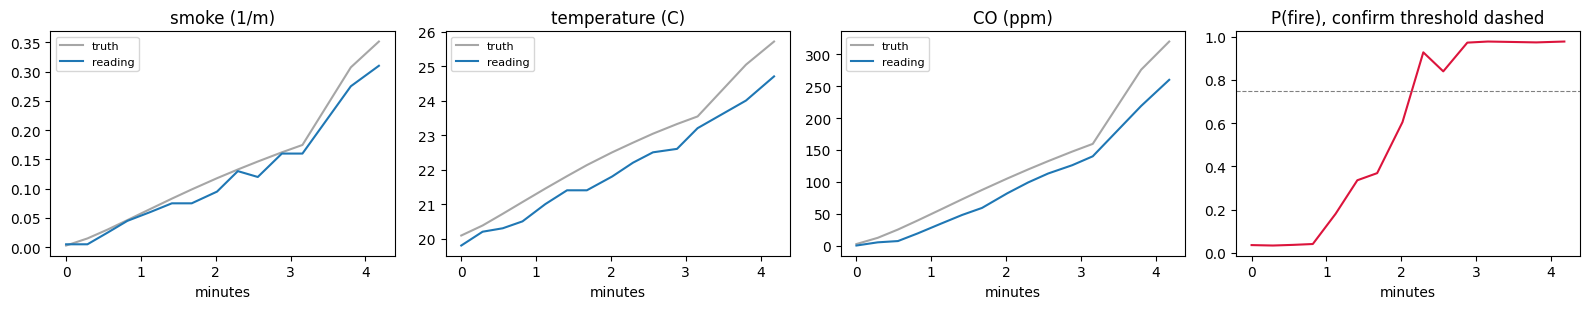

In [24]:
# The same data the Room detail panel charts, fetched and plotted here.
import urllib.parse

import matplotlib.pyplot as plt

# The '/' in a room key has to be percent-encoded to survive the URL.
track = api('/api/history?space=' + urllib.parse.quote(target['key'], safe=''))
columns = track['columns']
print(len(track['points']), 'samples')

if track['points']:
    # Each point is a plain list, so look up a column by its position.
    def column(name):
        index = columns.index(name)
        return [point[index] for point in track['points']]

    t0 = track['points'][0][0]
    minutes = [(t - t0) / 60 for t in column('t')]  # seconds since the first sample

    # Three charts comparing truth (grey) with the sensor reading (coloured):
    # the gap between the two lines is the sensor error.
    figure, axes = plt.subplots(1, 4, figsize=(16, 3.2))
    for axis, (field, label) in zip(axes, [('smoke', 'smoke (1/m)'),
                                           ('temperature', 'temperature (C)'),
                                           ('co', 'CO (ppm)')]):
        axis.plot(minutes, column('truth_' + field), color='0.65', label='truth')
        axis.plot(minutes, column('read_' + field), label='reading')
        axis.set_title(label)
        axis.set_xlabel('minutes')
        axis.legend(fontsize=8)

    # The fourth chart is the conclusion: P(fire) against the confirm threshold.
    axes[3].plot(minutes, column('p_fire'), color='crimson')
    axes[3].axhline(0.75, ls='--', lw=0.8, color='0.5')
    axes[3].set_title('P(fire), confirm threshold dashed')
    axes[3].set_xlabel('minutes')
    figure.tight_layout()
    plt.show()


In [25]:
# Why the system reached that probability. `value` is the raw feature, `weighted`
# is its push towards (+) or away from (-) fire. These are the bars in the UI.
for term in track['why']:
    bar = '#' * int(abs(term['weighted']) * 8)  # a crude text bar chart
    print(f"{term['name']:<22} raw={term['value']:>10.3f}   {term['weighted']:+6.2f}  {bar}")


bias                   raw=     1.000    -3.40  ###########################
smoke                  raw=     0.310    +0.99  #######
co                     raw=   260.000    +1.80  ##############
co_smoke_ratio         raw=   838.710    +4.00  ################################
temperature_rise       raw=     4.700    +0.26  ##
smoke_rate             raw=     0.104    +0.15  #
neighbour_agreement    raw=     0.000    +0.00  


In [26]:
# What the Export CSV button downloads: one row per sample per room, with a
# `label` column holding the true cause. That label is what makes it training data.
with urllib.request.urlopen(FIRELAB + '/api/export.csv', timeout=120) as response:
    csv_text = response.read().decode()

lines = csv_text.splitlines()
print(lines[0])          # the header row
for line in lines[1:4]:  # a few sample rows
    print(line)
print('...')
print(len(lines) - 1, 'rows')


space,level,room,label,t,truth_temperature,truth_smoke,truth_co,read_temperature,read_smoke,read_co,p_fire
level0/1540,level0,1540,none,28810.0,20.0,0.0,0.0,19.9,0.015,2.0,0.037
level0/1540,level0,1540,none,28827.1,20.0,0.0,0.0,20.0,0.01,0.0,0.033
level0/1540,level0,1540,none,28843.3,20.0,0.0,0.0,19.9,0.005,0.0,0.033
...
13384 rows


## 9. Replacing the rule with a model

`FusionRule` exists so the system is complete without a model, not because a rule
is the goal. It is also the baseline a trained model has to beat — this is
milestone 4 in `ARCHITECTURE.ipynb`, the one milestone not yet done. The seam is
built; the model is not. Swapping it is a two-step job.

**Step 1 — get labelled data.** Run a batch of scenarios and export. The CSV
carries the ground-truth label taken from the source kind, so the training set
writes itself.

**Step 2 — implement the protocol.**

```python
class TreeDetector:
    name = 'gbdt'

    def __init__(self, model):
        self._model = model

    def probability(self, features):
        return float(self._model.predict_proba([vector_of(features)])[0][1])

    def explain(self, features):
        # SHAP values map cleanly onto Contribution
        return [Contribution(name, value, weight)
                for name, value, weight in shap_terms(self._model, features)]
```

Then set `self.detector = TreeDetector(model)` in `Engine.__init__`. Nothing else
changes: the agent, the interlocks, the UI bars and the scorecard all work off
the protocol, not off `FusionRule`.


Keep `explain` honest. If the returned terms do not account for the score, thebars in the UI become decoration.

## 10. What this does not do

Every model is wrong somewhere, and the useful question is *where*. These are the
boundaries of this one. None of them is a bug to be reported; each is a decision,
and each is visible in the code.

### Routing acts on belief, not on truth

`actuation.danger()` is built from **agent states**, and an agent only exists for
a room where sensors have been deployed. A room with no sensors cannot alarm, so
it is never in `danger`, so the router will send people straight through it
however fiercely it is burning.

This is not a rounding error. The presets instrument the target room and its
immediate neighbours only, so in a 956-room building nearly every room on a given
escape route is unmonitored. `tenability.assess` already knows those rooms are
lethal and the Life-safety panel displays it — the router simply never asks.

Routing on the truth instead would be one line, and would be cheating: it would
put ground truth into a decision path, which is exactly the line `intelligence.py`
exists to defend and `tests/test_layering.py` now enforces. Leaving it as it is
makes *coverage gaps kill people*, which is the finding the project exists to
demonstrate. Watch the Life-safety panel during a run with sparse sensors.

### Routing avoids burning rooms, but not burning corridors

We publish every alarming room to BuildSim with `blocked`, and its walkable
router then refuses to route anyone *into* it. That works because a room has an
`entry` node and blocking removes it.

Corridors have no entry node — 41 of the 305 named spaces on level 0 — so
blocking one does nothing, and a route is almost entirely corridor. So BuildSim
will not hand us a path *into* a fire, but it will still hand us one *through* a
smoke-logged corridor, and `Evacuation._through_fire` is what rejects those. The
difference matters: a rejected path costs us the whole exit, where a blocked one
would have produced a detour to the same exit.

### Only one route is drawn

`Evacuation.display_route` is a single route — the way out of the burning room,
chosen deterministically so the line does not flicker. Everyone else is walking a
path the viewer never draws. The occupant markers still move along their own
routes; only the highlighted line is singular.

### Reset keeps some of the run on purpose, and some by omission

`session.reset` keeps the floor plans, the sensors you installed and your
settings — the Settings panel promises the last of those. It also keeps the
**clock**, whether the sim is **running**, the **journal** and the **RNG
stream**, so a repeated run does not repeat: `reseed` exists but reset does not
call it. `tests/test_reset.py` pins the whole contract, both halves.

### The detector is a baseline, not a result

`FusionRule` is hand-weighted. It is there to be beaten — see section 9 — and its
numbers were chosen to separate the six presets, not fitted to data.


## 11. Things that go wrong

| Symptom | Cause | Fix |
|---|---|---|
| No people in the 3D viewer | occupancysim is also running and overwrote them | stop it; only one service may write entities |
| People vanish after a while | they reached an exit and left | expected — check the Evacuation panel's *out* column |
| The Rooms table looks empty on a floor | no sensors deployed there | the floor dropdown shows the count per floor |
| A room shows `UNMONITORED` | it has no devices | deploy sensors to it |
| Readings show a dash | the sensor has not sampled yet, or is `dead` / `dropout` | wait one interval, or check the fault dropdown |
| P(fire) will not pass confirm | coverage below 3 caps the probability | deploy all three modalities |
| Nothing updates | the clock is paused | press Run |
| Alarm but no sprinkler | the interlock refused below 35 °C | expected in a smouldering fire; the request stays queued and fires if the room heats up |
| A person is permanently stranded | their room is missing from BuildSim's walkable graph | already handled — such rooms are excluded at placement |
| The UI feels heavy with every room monitored | snapshots get large at 956 rooms | monitor fewer rooms, or lower the speed |
| BuildSim floods the terminal | its request log | always redirect it to a file |
| `make deps` fails | `python3-venv` is missing on this machine | the Makefile prefers `uv`; install it if absent |

### Tests

```bash
cd firelab
make test
```

Runs four things: the domain unit tests, the layering guards that check the
dependency rule with `ast` instead of trusting the docstrings, one end-to-end
run per preset, and the evacuation router. None of them import anything outside the standard library or need
a service running, which is the practical payoff of the dependency rule.